# Análisis Exploratorio de Datos (EDA) — Dataset `corazon.csv`

**Predicción de cardiopatía (heart disease) — Análisis univariable, bivariable y multivariable**


## Autor: Carlos javier Palacios Sanchez

---

## 1. Objetivo del análisis

Este notebook desarrolla el **Análisis Exploratorio de Datos** completo sobre `corazon.csv`, un
conjunto de datos clínicos orientado a determinar la **presencia o ausencia de enfermedad
cardíaca** en un paciente a partir de variables demográficas, sintomatológicas y de resultados
de pruebas médicas (electrocardiograma, prueba de esfuerzo, analítica de sangre).

El proceso cubre:

1. Comprensión detallada de las características y del esquema de datos.
2. Identificación de la **preparación de datos** y la **ingeniería de atributos** necesarias para
   implementar un modelo de *machine learning*.
3. **Análisis univariable** de cada atributo: nombre, tipo de dato, % de nulos, duplicados, ruido
   y su tipología, utilidad para el proyecto y descripción estadística (tendencia central,
   dispersión, forma y tipo de distribución).
4. **Reglas de validación de datos** derivadas del análisis, para su uso en la etapa de ingesta.
5. Identificación del **atributo objetivo (target)**.
6. **Visualización** de los datos.
7. **Análisis bivariable** (relaciones entre pares de atributos).
8. **Análisis multivariable** (correlaciones, reducción de dimensionalidad, interacciones).
9. **Modelo heurístico manual** (solución simple viable) y su evaluación.
10. **Transformaciones** candidatas y **datos adicionales** que serían útiles.
11. Conclusiones.

> **Nota metodológica.** El dataset entregado contiene **ruido inyectado deliberadamente**
> (valores centinela sin sentido, valores faltantes y filas replicadas). Una parte importante de
> este EDA consiste precisamente en **detectar, cuantificar y documentar ese ruido**, y en
> traducir los hallazgos en reglas de validación reutilizables.

---
## 2. Configuración del entorno

In [31]:
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')
PAL = ['#3E7CB1', '#E4572E', '#76B041', '#F2A65A', '#8C6BB1', '#4FB0A5']
sns.set_palette(PAL)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['font.size'] = 9

print('pandas', pd.__version__, '| numpy', np.__version__, '| seaborn', sns.__version__)

pandas 3.0.5 | numpy 2.5.2 | seaborn 0.13.2


---
## 3. Carga de datos y comprensión del esquema

Se carga el fichero **forzando el tipo `str` en todas las columnas**. Esta decisión es
intencionada: si dejamos que pandas infiera los tipos, las cadenas basura provocarían que
columnas numéricas se lean como `object` (perdiendo información) o que pandas convierta
silenciosamente parte del contenido. Leyendo todo como texto conservamos **el dato crudo tal cual
llegó**, que es lo que necesitamos auditar.

In [32]:
RUTA = '/mnt/c/Users/KATANA/Heart_project/data/01_raw/corazon.csv'   # el CSV debe estar junto al notebook

raw = pd.read_csv(RUTA, dtype=str, keep_default_na=True)

print(f'Filas    : {raw.shape[0]:,}')
print(f'Columnas : {raw.shape[1]}')
print(f'Memoria  : {raw.memory_usage(deep=True).sum()/1024**2:,.2f} MB')
raw.head(10)

Filas    : 3,030
Columnas : 14
Memoria  : 0.50 MB


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0
5,56,Male,nontypical,120,236,0,normal,178,0,0.8,1,0.0,normal,0
6,62,Female,asymptomatic,140,268,0,left ventricular hypertrophy,160,0,3.6,3,2.0,normal,1
7,57,Female,asymptomatic,120,354,0,normal,163,1,0.6,1,0.0,normal,0
8,63,Male,asymptomatic,130,254,0,left ventricular hypertrophy,147,0,1.4,2,1.0,reversable,1
9,53,Male,asymptomatic,140,203,1,left ventricular hypertrophy,155,1,3.1,3,0.0,reversable,1


In [33]:
# Esquema tal como lo infiere pandas por defecto (para contrastar)
pd.read_csv(RUTA).dtypes.to_frame('dtype inferido por pandas')

,dtype inferido por pandas
age,str
sex,str
chest_pain,str
rest_bp,str
chol,str
fbs,float64
rest_ecg,str
max_hr,str
exang,str
old_peak,str


### 3.1 Diccionario de datos

El conjunto corresponde a la familia de datos **Heart Disease (Cleveland, UCI)**. El significado
clínico de cada atributo es el siguiente:

| # | Atributo | Significado clínico | Tipo semántico esperado |
|---|----------|--------------------|--------------------------|
| 1 | `age` | Edad del paciente en años | Numérico entero, acotado (~29–77) |
| 2 | `sex` | Sexo biológico | Categórico nominal binario (`Male`/`Female`) |
| 3 | `chest_pain` | Tipo de dolor torácico: `typical` (angina típica), `nontypical` (angina atípica), `nonanginal` (dolor no anginoso), `asymptomatic` (asintomático) | Categórico nominal (4 niveles) |
| 4 | `rest_bp` | Presión arterial sistólica en reposo al ingreso (mm Hg) | Numérico entero, acotado |
| 5 | `chol` | Colesterol sérico total (mg/dl) | Numérico entero, acotado |
| 6 | `fbs` | Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no) | Categórico binario (booleano) |
| 7 | `rest_ecg` | Resultado del ECG en reposo: `normal`, `ST-T wave abnormality`, `left ventricular hypertrophy` | Categórico nominal (3 niveles) |
| 8 | `max_hr` | Frecuencia cardíaca máxima alcanzada en prueba de esfuerzo (lpm) | Numérico entero, acotado |
| 9 | `exang` | Angina inducida por el ejercicio (1 = sí, 0 = no) | Categórico binario |
| 10 | `old_peak` | Depresión del segmento ST inducida por ejercicio respecto al reposo | Numérico continuo (float), acotado ≥ 0 |
| 11 | `slope` | Pendiente del segmento ST en el pico de ejercicio: 1 = ascendente, 2 = plana, 3 = descendente | **Categórico ordinal** (1 < 2 < 3) |
| 12 | `ca` | Nº de vasos principales coloreados por fluoroscopia (0–3) | **Numérico discreto / ordinal** |
| 13 | `thal` | Talasemia / defecto de perfusión: `normal`, `fixed` (defecto fijo), `reversable` (defecto reversible) | Categórico nominal (3 niveles) |
| 14 | `disease` | **TARGET** — presencia de enfermedad cardíaca (1 = sí, 0 = no) | Categórico binario |

**Observación clave sobre el esquema:** ninguna columna del CSV llega con el tipo correcto,
porque *todas* han sido contaminadas con cadenas de texto arbitrarias. El esquema real de destino
(el que debe imponerse en la ingesta) es el de la tabla anterior; el esquema de origen es
"todo texto".

### 3.2 Cardinalidad y muestra de valores por columna

Primer barrido para ver, columna a columna, cuántos valores distintos hay y cómo son.

In [34]:
filas = []
for c in raw.columns:
    vals = raw[c].dropna().unique()
    filas.append({
        'atributo'      : c,
        'n_unicos'      : len(vals),
        'n_no_nulos'    : int(raw[c].notna().sum()),
        'muestra_valores': ', '.join(map(str, sorted(vals, key=str)[:8])) + (' …' if len(vals) > 8 else '')
    })
resumen_card = pd.DataFrame(filas)
resumen_card

,atributo,n_unicos,n_no_nulos,muestra_valores
0,age,43,3000,"29, 34, 35, 37, 38, 39, 40, 41 …"
1,sex,5,2969,"2345, 45, 765, Female, Male"
2,chest_pain,7,2947,"2345, 2435, 3456, asymptomatic, nonanginal, no..."
3,rest_bp,52,2949,"100, 101, 102, 104, 105, 106, 108, 110 …"
4,chol,154,2945,"126, 131, 141, 149, 157, 160, 164, 166 …"
5,fbs,2,2933,"0, 1"
6,rest_ecg,8,2837,"3563, 36653, 435647, 5653, 5678, ST-T wave abn..."
7,max_hr,92,2859,"103, 105, 106, 108, 109, 111, 112, 113 …"
8,exang,4,2879,"0, 1, adfs, f"
9,old_peak,42,2880,"0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7 …"


---
## 4. Calidad de los datos: nulos, duplicados y ruido

Antes de describir estadísticamente nada, hay que saber **qué parte del dataset es real**.
Describir la media de una columna que contiene el valor `2345` en un campo de sexo sería un error.

### 4.1 Valores nulos

Porcentaje de nulos por atributo, y patrón de "nulidad" (¿faltan al azar o en bloque?).

In [35]:
nulos = pd.DataFrame({
    'n_nulos'  : raw.isna().sum(),
    'pct_nulos': (raw.isna().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
nulos

,n_nulos,pct_nulos
rest_ecg,193,6.370
max_hr,171,5.640
ca,162,5.350
exang,151,4.980
slope,151,4.980
old_peak,150,4.950
thal,126,4.160
disease,106,3.500
fbs,97,3.200
chol,85,2.810


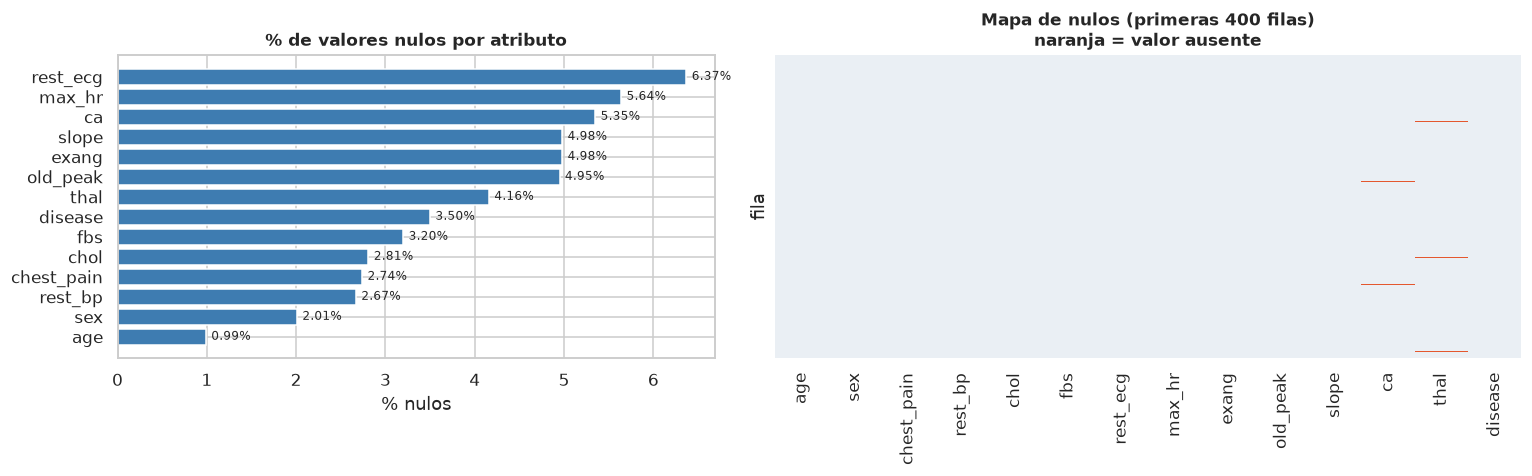

Filas sin ningún nulo : 2,712 (89.5%)
Filas 100% nulas      : 15
Celdas nulas totales  : 1,647 (3.88% del total de celdas)


In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={'width_ratios': [1, 1.25]})

nulos_ord = nulos.sort_values('pct_nulos')
ax[0].barh(nulos_ord.index, nulos_ord['pct_nulos'], color=PAL[0])
ax[0].set_title('% de valores nulos por atributo')
ax[0].set_xlabel('% nulos')
for i, v in enumerate(nulos_ord['pct_nulos']):
    ax[0].text(v + 0.06, i, f'{v:.2f}%', va='center', fontsize=8)

sns.heatmap(raw.isna().iloc[:400], cbar=False, cmap=['#EAEFF4', PAL[1]], ax=ax[1])
ax[1].set_title('Mapa de nulos (primeras 400 filas)\nnaranja = valor ausente')
ax[1].set_ylabel('fila'); ax[1].set_yticks([])

plt.tight_layout(); plt.show()

print(f"Filas sin ningún nulo : {raw.notna().all(axis=1).sum():,} "
      f"({raw.notna().all(axis=1).mean()*100:.1f}%)")
print(f"Filas 100% nulas      : {raw.isna().all(axis=1).sum():,}")
print(f"Celdas nulas totales  : {raw.isna().sum().sum():,} "
      f"({raw.isna().values.mean()*100:.2f}% del total de celdas)")

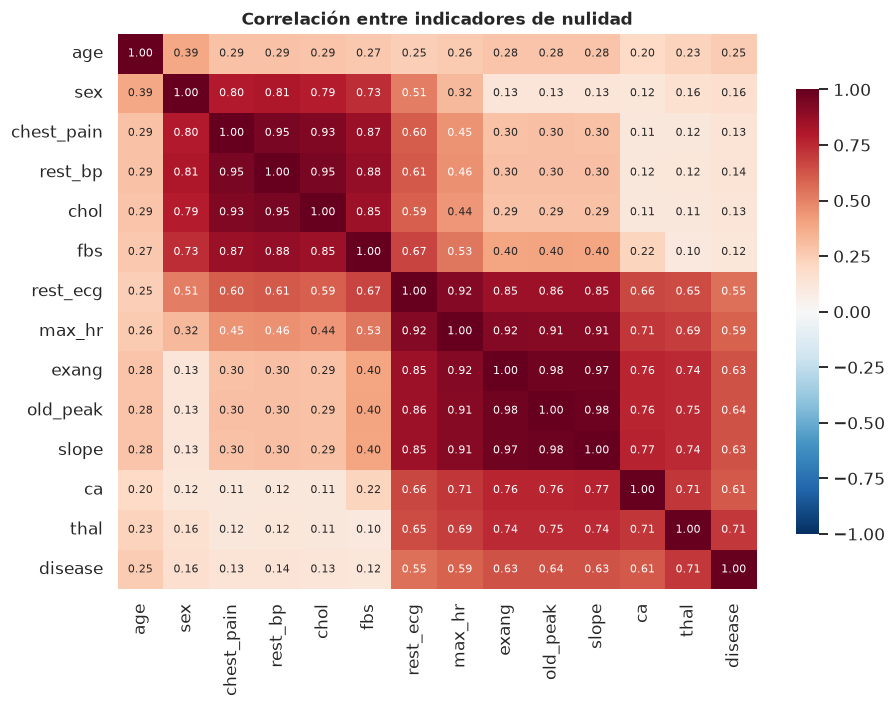

In [37]:
# ¿Los nulos están correlacionados entre columnas? (¿faltan juntos?)
corr_nulos = raw.isna().astype(int).corr()
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr_nulos, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot_kws={'size': 7}, cbar_kws={'shrink': .8})
plt.title('Correlación entre indicadores de nulidad')
plt.tight_layout(); plt.show()

**Lectura.** Los nulos aparecen repartidos por todas las columnas en proporciones del orden del
1–6 %, sin bloques contiguos y con correlaciones de nulidad bajas salvo por un pequeño grupo de
filas **completamente vacías**. Esto es compatible con un mecanismo **MCAR** (*Missing Completely
At Random*): faltantes inyectados al azar, no informativos. La consecuencia práctica es
importante: **la ausencia de valor no es una señal predictiva**, así que imputar es preferible a
crear una categoría "desconocido" con significado propio.

Las filas totalmente nulas son un caso aparte: no son "un paciente con datos faltantes" sino
**registros vacíos** que deben eliminarse en la ingesta.

### 4.2 Filas exactamente duplicadas

El enunciado pide comprobar duplicados **de filas y de columnas**.

In [38]:
dup_exactas = raw.duplicated().sum()
print(f'Filas duplicadas (2ª aparición en adelante): {dup_exactas:,}  '
      f'({dup_exactas/len(raw)*100:.1f}% del dataset)')
print(f'Filas implicadas en algún duplicado       : {raw.duplicated(keep=False).sum():,}')
print(f'Filas únicas reales                       : {len(raw.drop_duplicates()):,}')

conteo_rep = (raw.dropna(how='all')
                 .groupby(list(raw.columns), dropna=False)
                 .size().sort_values(ascending=False))
print('\nDistribución del nº de repeticiones por registro único:')
print(conteo_rep.value_counts().sort_index().rename_axis('veces_repetido').to_frame('n_registros'))

Filas duplicadas (2ª aparición en adelante): 2,462  (81.3% del dataset)
Filas implicadas en algún duplicado       : 2,775
Filas únicas reales                       : 568

Distribución del nº de repeticiones por registro único:
                n_registros
veces_repetido             
1                       255
2                         9
7                         5
8                        89
9                        95
10                      114


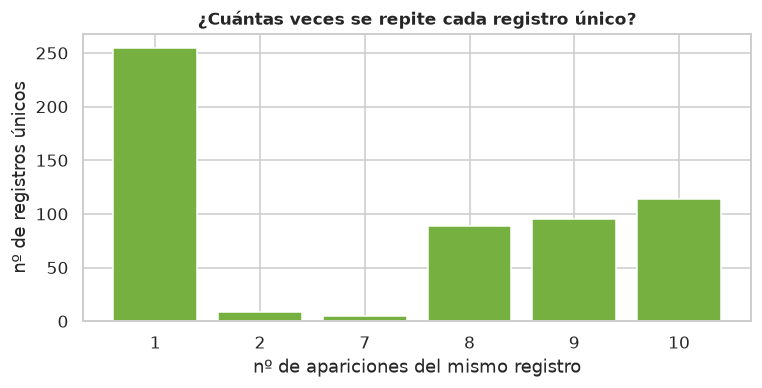

Ejemplo de registro repetido 10 veces:


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
132,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
435,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
738,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
1041,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
1344,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
1647,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
1950,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
2253,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
2556,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0
2859,29,Male,nontypical,130,204,0,left ventricular hypertrophy,202,0,0.0,1,0.0,normal,0


In [39]:
plt.figure(figsize=(7, 3.6))
vc = conteo_rep.value_counts().sort_index()
plt.bar(vc.index.astype(str), vc.values, color=PAL[2])
plt.title('¿Cuántas veces se repite cada registro único?')
plt.xlabel('nº de apariciones del mismo registro'); plt.ylabel('nº de registros únicos')
plt.tight_layout(); plt.show()

print('Ejemplo de registro repetido 10 veces:')
display(raw[raw.duplicated(keep=False)].sort_values(list(raw.columns)).head(10))

**Hallazgo crítico.** El dataset **no contiene ~3.030 pacientes distintos**. Es un conjunto de
unos **300 registros originales replicado entre 8 y 10 veces** (114 registros aparecen 10 veces,
95 aparecen 9 veces, 89 aparecen 8 veces), sobre el que después se
inyectaron nulos y basura (por eso no todas las copias son idénticas entre sí: algunas copias
tienen celdas corrompidas y ya no coinciden con sus hermanas).

Esto tiene tres consecuencias que condicionan todo el proyecto:

1. **El tamaño muestral efectivo es varias veces menor** que el aparente: el 81 % de las filas
   son repeticiones y solo quedan **568 filas únicas** (297 de ellas completas, que es
   esencialmente la cohorte original de ~300 pacientes). Cualquier intervalo de confianza,
   *p*-valor o error estándar calculado sobre las 3.030 filas está **artificialmente estrechado
   por un factor de entre √5 y √10 (≈ 2–3)**. Los tests de hipótesis de este notebook se reportan,
   por tanto, como indicativos y no como evidencia formal.
2. **Fuga de datos (*data leakage*) garantizada** si se hace un `train_test_split` aleatorio: el
   mismo paciente aparecería simultáneamente en entrenamiento y en test, y el modelo obtendría
   una exactitud inflada por memorización. **La deduplicación debe hacerse antes de partir los
   datos**, sin excepción.
3. La replicación **no aporta información nueva**: no mejora el aprendizaje, solo multiplica el
   coste de cómputo.

### 4.3 Columnas duplicadas

Se comprueba si existen dos columnas con contenido idéntico (redundancia estructural).

In [40]:
pares_iguales = []
cols = list(raw.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = raw[cols[i]], raw[cols[j]]
        if a.equals(b):
            pares_iguales.append((cols[i], cols[j]))

print('Columnas exactamente duplicadas:', pares_iguales if pares_iguales else 'ninguna')

# Columnas constantes o casi constantes (varianza nula → inútiles para modelar)
casi_const = {c: raw[c].value_counts(normalize=True, dropna=True).max() for c in raw.columns}
print('\nFrecuencia de la moda por columna (1.0 = columna constante):')
print(pd.Series(casi_const).sort_values(ascending=False).round(3).to_string())

Columnas exactamente duplicadas: ninguna

Frecuencia de la moda por columna (1.0 = columna constante):
fbs          0.852
sex          0.679
exang        0.670
ca           0.587
thal         0.551
disease      0.539
rest_ecg     0.497
chest_pain   0.473
slope        0.470
old_peak     0.328
rest_bp      0.122
age          0.062
max_hr       0.036
chol         0.020


No hay columnas duplicadas ni constantes: los 14 atributos son estructuralmente distintos y
todos aportan variabilidad.

### 4.4 Detección de ruido: valores fuera del dominio

Este es el punto central del control de calidad. Para cada atributo se define su **dominio
válido** (a partir del diccionario de datos y del conocimiento clínico) y se cuenta cuántos
valores caen fuera.

In [41]:
# Dominios válidos declarados
CATEGORICAS_VALIDAS = {
    'sex'       : {'Male', 'Female'},
    'chest_pain': {'typical', 'nontypical', 'nonanginal', 'asymptomatic'},
    'rest_ecg'  : {'normal', 'ST-T wave abnormality', 'left ventricular hypertrophy'},
    'thal'      : {'normal', 'fixed', 'reversable'},
    'fbs'       : {'0', '1'},
    'exang'     : {'0', '1'},
    'slope'     : {'1', '2', '3'},
    'ca'        : {'0', '1', '2', '3'},
    'disease'   : {'0', '1'},
}
NUMERICAS = ['age', 'rest_bp', 'chol', 'max_hr', 'old_peak']

def normaliza(s):
    """Quita espacios sobrantes y normaliza floats enteros ('0.0' -> '0')."""
    s = s.astype('string').str.strip()
    return s.str.replace(r'^(\d+)\.0$', r'\1', regex=True)

informe = []
for c in raw.columns:
    s = normaliza(raw[c])
    nn = s.notna().sum()
    if c in CATEGORICAS_VALIDAS:
        malos = s[s.notna() & ~s.isin(CATEGORICAS_VALIDAS[c])]
    else:
        num = pd.to_numeric(s, errors='coerce')
        malos = s[s.notna() & num.isna()]
    informe.append({
        'atributo'      : c,
        'n_fuera_dominio': len(malos),
        'pct_fuera'     : round(len(malos) / nn * 100, 2) if nn else np.nan,
        'valores_basura': ', '.join(sorted(malos.unique(), key=str)[:8])
    })
informe_ruido = pd.DataFrame(informe)
informe_ruido

,atributo,n_fuera_dominio,pct_fuera,valores_basura
0,age,2,0.070,"fggfds, sdg"
1,sex,3,0.100,"2345, 45, 765"
2,chest_pain,3,0.100,"2345, 2435, 3456"
3,rest_bp,2,0.070,"fsgh, wety"
4,chol,2,0.070,"sfdywe, wtey"
5,fbs,0,0.000,
6,rest_ecg,5,0.180,"3563, 36653, 435647, 5653, 5678"
7,max_hr,1,0.030,adfs
8,exang,2,0.070,"adfs, f"
9,old_peak,2,0.070,"afd, asd"


Celdas con valor fuera de dominio: 33 (0.08% de las celdas informadas)
Filas afectadas por al menos un valor basura: 25


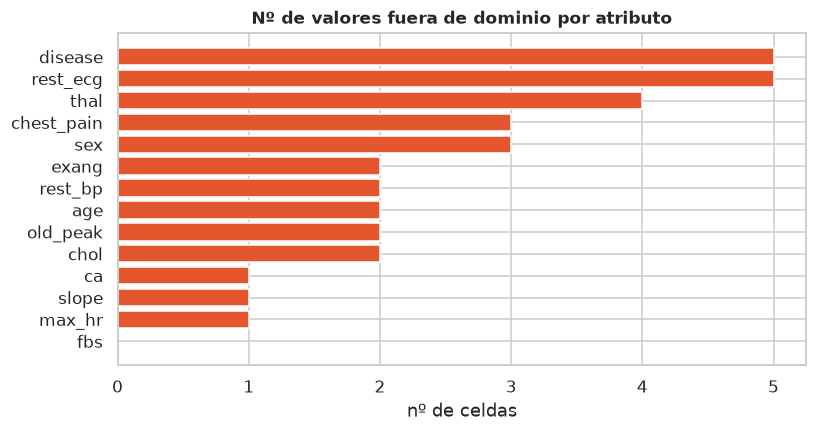

In [42]:
tot_basura = informe_ruido['n_fuera_dominio'].sum()
print(f'Celdas con valor fuera de dominio: {tot_basura:,} '
      f'({tot_basura/(raw.notna().sum().sum())*100:.2f}% de las celdas informadas)')
print(f'Filas afectadas por al menos un valor basura: ', end='')

mask_basura = pd.DataFrame(False, index=raw.index, columns=raw.columns)
for c in raw.columns:
    s = normaliza(raw[c])
    if c in CATEGORICAS_VALIDAS:
        mask_basura[c] = s.notna() & ~s.isin(CATEGORICAS_VALIDAS[c])
    else:
        mask_basura[c] = s.notna() & pd.to_numeric(s, errors='coerce').isna()
print(f'{mask_basura.any(axis=1).sum():,}')

plt.figure(figsize=(7.5, 4))
serie = informe_ruido.set_index('atributo')['n_fuera_dominio'].sort_values()
plt.barh(serie.index, serie.values, color=PAL[1])
plt.title('Nº de valores fuera de dominio por atributo')
plt.xlabel('nº de celdas')
plt.tight_layout(); plt.show()

#### Tipología del ruido encontrado

El enunciado pide clasificar el ruido. En este dataset conviven **cinco tipos claramente
diferenciables**, y es importante no tratarlos igual:

| Tipo de ruido | Dónde aparece | Descripción | Tratamiento |
|---|---|---|---|
| **Ruido sintáctico / de dominio** (valores centinela inválidos) | Todas las columnas: `2345`, `765` en `sex`; `fggfds`, `sdg` en `age`; `wety` en `rest_bp`; `87654` en `thal`; `fsg`, `gsfdg` en `disease` | Cadenas arbitrarias, numéricas o alfabéticas, sin ningún significado en el dominio. Corrupción **artificial**, no un error de medida | Convertir a `NaN` y tratar como faltante. **Nunca** imputar por interpolación de su valor literal |
| **Ruido de codificación** | `exang` contiene `'f'` y `'adfs'`; `slope`/`ca` contienen `'afd'`; `ca` mezcla `'0'` y `'0.0'` | Mismo concepto escrito de formas distintas, o etiquetas de un vocabulario ajeno | Normalizar cadenas (trim, casefold, canonicalización) antes de validar |
| **Ruido de formato / espacios** | `rest_ecg` = `'left ventricular hypertrophy '` (espacio final) | Espacio en blanco al final que crea una categoría "fantasma" | `str.strip()` sistemático en la ingesta |
| **Ruido estocástico (variabilidad natural)** | `rest_bp`, `chol`, `max_hr`, `old_peak` | Variabilidad biológica y error de medición real del instrumento clínico. Es **inherente y legítimo** | No se elimina. Se modela: es la varianza irreducible del problema |
| **Errores de redondeo / discretización** | `old_peak` (1 decimal), `chol` y `rest_bp` (enteros, medidos en múltiplos de 2 y de 5–10) | Pérdida de precisión por redondeo del instrumento o del protocolo de registro | Aceptable; conviene documentarlo porque limita la resolución útil del atributo |

Además hay **valores atípicos (*outliers*) legítimos**, que no son ruido sintáctico sino
observaciones reales extremas (p. ej. `chol` = 564 mg/dl es una hipercolesterolemia severa pero
clínicamente posible). Se analizan más adelante y **no deben eliminarse a ciegas**.

**Punto importante:** el ruido inyectado en las columnas numéricas es de dos clases distintas.
Cadenas como `fggfds` en `age` son triviales de detectar (no parsean). Pero valores como `2345`
en `sex` o `36653` en `rest_ecg` **sí parsean como números**: si alguien hubiera cargado el CSV
con inferencia automática de tipos y hubiera aplicado un `LabelEncoder` sin validar, esos valores
se habrían convertido en categorías legítimas y habrían entrado al modelo sin levantar ninguna
alarma. Es exactamente el motivo por el que hace falta una **validación por dominio explícito**,
no solo una validación por tipo.

---
## 5. Construcción del dataset tipado

Se aplica la primera capa de preparación: normalización de cadenas, casteo a los tipos correctos
y conversión de todo lo que quede fuera de dominio a `NaN`. **No se imputa todavía** — la
imputación pertenece a la fase de modelado y debe ajustarse solo con datos de entrenamiento para
evitar fuga.

In [43]:
def construir_tipado(df):
    d = pd.DataFrame(index=df.index)

    # --- numéricos continuos/discretos ---
    for c in ['age', 'rest_bp', 'chol', 'max_hr']:
        d[c] = pd.to_numeric(normaliza(df[c]), errors='coerce').astype('Float64')
    d['old_peak'] = pd.to_numeric(normaliza(df['old_peak']), errors='coerce').astype('Float64')

    # --- binarios ---
    for c in ['fbs', 'exang', 'disease']:
        s = normaliza(df[c])
        d[c] = pd.to_numeric(s.where(s.isin({'0', '1'})), errors='coerce').astype('Int8')

    # --- ordinales / discretos acotados ---
    s = normaliza(df['slope']); d['slope'] = pd.to_numeric(s.where(s.isin({'1','2','3'})), errors='coerce').astype('Int8')
    s = normaliza(df['ca']);    d['ca']    = pd.to_numeric(s.where(s.isin({'0','1','2','3'})), errors='coerce').astype('Int8')

    # --- categóricos nominales ---
    for c in ['sex', 'chest_pain', 'rest_ecg', 'thal']:
        s = normaliza(df[c])
        d[c] = s.where(s.isin(CATEGORICAS_VALIDAS[c])).astype('category')

    # rangos fisiológicos imposibles -> NaN (ver reglas de validación, sección 7)
    d.loc[~d['age'].between(18, 100), 'age'] = pd.NA
    d.loc[~d['rest_bp'].between(70, 250), 'rest_bp'] = pd.NA
    d.loc[~d['chol'].between(80, 700), 'chol'] = pd.NA
    d.loc[~d['max_hr'].between(50, 230), 'max_hr'] = pd.NA
    d.loc[~d['old_peak'].between(0, 10), 'old_peak'] = pd.NA

    orden = ['age','sex','chest_pain','rest_bp','chol','fbs','rest_ecg',
             'max_hr','exang','old_peak','slope','ca','thal','disease']
    return d[orden]

df = construir_tipado(raw)

print('Esquema tipado resultante:')
display(df.dtypes.to_frame('dtype'))
print(f'Nulos tras tipado: {df.isna().sum().sum():,} '
      f'(antes: {raw.isna().sum().sum():,}; diferencia = ruido convertido a NaN)')
df.head()

Esquema tipado resultante:


,dtype
age,Float64
sex,category
chest_pain,category
rest_bp,Float64
chol,Float64
fbs,Int8
rest_ecg,category
max_hr,Float64
exang,Int8
old_peak,Float64


Nulos tras tipado: 1,680 (antes: 1,647; diferencia = ruido convertido a NaN)


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63.000,Male,typical,145.000,233.000,1,left ventricular hypertrophy,150.000,0,2.300,3,0,fixed,0
1,67.000,Male,asymptomatic,160.000,286.000,0,left ventricular hypertrophy,108.000,1,1.500,2,3,normal,1
2,67.000,Male,asymptomatic,120.000,229.000,0,left ventricular hypertrophy,129.000,1,2.600,2,2,reversable,1
3,37.000,Male,nonanginal,130.000,250.000,0,normal,187.000,0,3.500,3,0,normal,0
4,41.000,Female,nontypical,130.000,204.000,0,left ventricular hypertrophy,172.000,0,1.400,1,0,normal,0


In [44]:
# Dataset deduplicado: base honesta para el análisis estadístico
df_dedup = df.dropna(how='all').drop_duplicates().reset_index(drop=True)

print(f'df completo   : {len(df):,} filas')
print(f'df deduplicado: {len(df_dedup):,} filas')
print(f'Factor de replicación aparente: x{len(df)/len(df_dedup):.1f}')

# Núcleo limpio: filas deduplicadas y sin ningún faltante
df_limpio = df_dedup.dropna().reset_index(drop=True)
print(f'df limpio (dedup + sin nulos): {len(df_limpio):,} filas '
      f'({len(df_limpio)/len(df_dedup)*100:.1f}% de las únicas)')

df completo   : 3,030 filas
df deduplicado: 567 filas
Factor de replicación aparente: x5.3
df limpio (dedup + sin nulos): 297 filas (52.4% de las únicas)


> **Sobre qué conjunto se analiza cada cosa.** A partir de aquí se usan tres vistas:
> `df` (todo, tipado), `df_dedup` (sin filas repetidas) y `df_limpio` (sin repeticiones ni
> faltantes). Las **estadísticas descriptivas y las correlaciones se reportan sobre `df_dedup` /
> `df_limpio`**, porque calcularlas sobre las 3.030 filas replicadas daría los mismos valores
> centrales pero con una precisión falsa. Los recuentos de calidad de datos, en cambio, se
> reportan sobre el fichero completo, que es lo que realmente llega al sistema.

Nótese que `df_dedup` tiene bastantes más filas que los ~300 registros originales: las copias que
recibieron nulos o basura en distintas celdas dejaron de ser idénticas entre sí, de modo que la
deduplicación exacta no puede recuperarlas. Es un efecto secundario típico de la corrupción de
datos: **destruye la capacidad de detectar duplicados exactos**. En un sistema real haría falta
*deduplicación difusa* (por clave de paciente o por similitud de registro).

---
## 6. Análisis univariable

Se estudia cada atributo por separado siguiendo el guion pedido: **nombre, tipo de dato,
% de nulos, duplicados, ruido, utilidad y descripción estadística**.

### 6.1 Ficha resumen de todos los atributos

In [45]:
TIPOS = {
 'age'       : ('Numérico entero, acotado',             'Discreto (razón)'),
 'sex'       : ('Categórico nominal binario',           'Nominal'),
 'chest_pain': ('Categórico nominal (4 niveles)',       'Nominal'),
 'rest_bp'   : ('Numérico entero, acotado',             'Continuo discretizado (razón)'),
 'chol'      : ('Numérico entero, acotado',             'Continuo discretizado (razón)'),
 'fbs'       : ('Categórico binario (booleano)',        'Nominal binario'),
 'rest_ecg'  : ('Categórico nominal (3 niveles)',       'Nominal'),
 'max_hr'    : ('Numérico entero, acotado',             'Continuo discretizado (razón)'),
 'exang'     : ('Categórico binario (booleano)',        'Nominal binario'),
 'old_peak'  : ('Numérico float, acotado ≥ 0',          'Continuo (razón), 1 decimal'),
 'slope'     : ('Categórico ORDINAL (1<2<3)',           'Ordinal'),
 'ca'        : ('Numérico discreto / ordinal (0–3)',    'Ordinal / conteo'),
 'thal'      : ('Categórico nominal (3 niveles)',       'Nominal'),
 'disease'   : ('Categórico binario — TARGET',          'Nominal binario'),
}
UTILIDAD = {
 'age':'Sí — factor de riesgo cardiovascular de primer orden',
 'sex':'Sí — prevalencia muy distinta por sexo',
 'chest_pain':'Sí — de los predictores clínicos más fuertes',
 'rest_bp':'Media — señal débil pero clínicamente relevante',
 'chol':'Media — señal sorprendentemente débil en esta cohorte',
 'fbs':'Baja — casi sin poder discriminante aquí',
 'rest_ecg':'Baja/Media — señal moderada',
 'max_hr':'Sí — predictor fuerte (inverso)',
 'exang':'Sí — predictor fuerte',
 'old_peak':'Sí — predictor fuerte',
 'slope':'Sí — predictor fuerte',
 'ca':'Sí — el predictor individual más fuerte',
 'thal':'Sí — predictor muy fuerte',
 'disease':'TARGET — variable a predecir',
}
RUIDO = {
 'age':'Sintáctico (fggfds, sdg) + estocástico leve',
 'sex':'Sintáctico numérico (2345, 45, 765) — parsea como número',
 'chest_pain':'Sintáctico numérico (2345, 2435, 3456)',
 'rest_bp':'Sintáctico (wety, fsgh) + estocástico + redondeo a múltiplos de 10',
 'chol':'Sintáctico (wtey, sfdywe) + estocástico + outliers reales',
 'fbs':'Solo faltantes',
 'rest_ecg':'Sintáctico numérico + espacio final en una categoría',
 'max_hr':'Sintáctico (adfs) + estocástico',
 'exang':'De codificación (f, adfs)',
 'old_peak':'Sintáctico (afd, asd) + redondeo a 0.1 + masa en cero',
 'slope':'De codificación (afd)',
 'ca':'De codificación (afd) + formato 0.0 vs 0',
 'thal':'Sintáctico numérico (87654, 365635463, 56, 53646)',
 'disease':'Sintáctico alfabético (fsg, gsfdg, g, sf, fsdg)',
}

ficha = pd.DataFrame({
    'tipo_dato'   : {c: TIPOS[c][0] for c in raw.columns},
    'escala'      : {c: TIPOS[c][1] for c in raw.columns},
    'pct_nulos_orig': (raw.isna().mean()*100).round(2),
    'pct_ruido'   : informe_ruido.set_index('atributo')['pct_fuera'],
    'pct_nulos_tras_tipado': (df.isna().mean()*100).round(2),
    'n_unicos_validos': df.nunique(),
    'tipo_de_ruido': RUIDO,
    'utilidad'    : UTILIDAD,
})
ficha

,tipo_dato,escala,pct_nulos_orig,pct_ruido,pct_nulos_tras_tipado,n_unicos_validos,tipo_de_ruido,utilidad
age,"Numérico entero, acotado",Discreto (razón),0.990,0.070,1.060,41,"Sintáctico (fggfds, sdg) + estocástico leve",Sí — factor de riesgo cardiovascular de primer...
sex,Categórico nominal binario,Nominal,2.010,0.100,2.110,2,"Sintáctico numérico (2345, 45, 765) — parsea c...",Sí — prevalencia muy distinta por sexo
chest_pain,Categórico nominal (4 niveles),Nominal,2.740,0.100,2.840,4,"Sintáctico numérico (2345, 2435, 3456)",Sí — de los predictores clínicos más fuertes
rest_bp,"Numérico entero, acotado",Continuo discretizado (razón),2.670,0.070,2.740,50,"Sintáctico (wety, fsgh) + estocástico + redond...",Media — señal débil pero clínicamente relevante
chol,"Numérico entero, acotado",Continuo discretizado (razón),2.810,0.070,2.870,152,"Sintáctico (wtey, sfdywe) + estocástico + outl...",Media — señal sorprendentemente débil en esta ...
fbs,Categórico binario (booleano),Nominal binario,3.200,0.000,3.200,2,Solo faltantes,Baja — casi sin poder discriminante aquí
rest_ecg,Categórico nominal (3 niveles),Nominal,6.370,0.180,6.530,3,Sintáctico numérico + espacio final en una cat...,Baja/Media — señal moderada
max_hr,"Numérico entero, acotado",Continuo discretizado (razón),5.640,0.030,5.680,91,Sintáctico (adfs) + estocástico,Sí — predictor fuerte (inverso)
exang,Categórico binario (booleano),Nominal binario,4.980,0.070,5.050,2,"De codificación (f, adfs)",Sí — predictor fuerte
old_peak,"Numérico float, acotado ≥ 0","Continuo (razón), 1 decimal",4.950,0.070,5.020,40,"Sintáctico (afd, asd) + redondeo a 0.1 + masa ...",Sí — predictor fuerte


### 6.2 Atributos numéricos — descripción estadística completa

Para cada variable numérica se calculan **tendencia central** (media, mediana, moda, mín, máx),
**dispersión** (rango, IQR, cuartiles, varianza, desviación típica, coeficiente de variación) y
**forma** (asimetría y curtosis).

In [46]:
NUM = ['age', 'rest_bp', 'chol', 'max_hr', 'old_peak', 'ca']

def describe_num(s):
    x = pd.to_numeric(s.dropna(), errors='coerce').astype(float)
    q1, q3 = x.quantile([.25, .75])
    return pd.Series({
        'n'          : len(x),
        'media'      : x.mean(),
        'mediana'    : x.median(),
        'moda'       : x.mode().iloc[0] if not x.mode().empty else np.nan,
        'min'        : x.min(),
        'max'        : x.max(),
        'rango'      : x.max() - x.min(),
        'Q1'         : q1,
        'Q3'         : q3,
        'IQR'        : q3 - q1,
        'varianza'   : x.var(),
        'desv_est'   : x.std(),
        'CV_%'       : x.std() / x.mean() * 100 if x.mean() else np.nan,
        'skewness'   : stats.skew(x),
        'kurtosis'   : stats.kurtosis(x),   # exceso de curtosis (0 = normal)
        'p5'         : x.quantile(.05),
        'p95'        : x.quantile(.95),
    })

desc_num = pd.DataFrame({c: describe_num(df_dedup[c]) for c in NUM}).T
desc_num.round(3)

,n,media,mediana,moda,min,max,rango,Q1,Q3,IQR,varianza,desv_est,CV_%,skewness,kurtosis,p5,p95
age,550.000,54.658,56.000,58.000,29.000,77.000,48.000,47.250,61.000,13.750,82.102,9.061,16.578,-0.148,-0.582,40.000,68.000
rest_bp,499.000,131.122,130.000,130.000,94.000,200.000,106.000,120.000,140.000,20.000,298.216,17.269,13.170,0.621,0.545,106.000,160.000
chol,495.000,247.923,243.000,197.000,126.000,564.000,438.000,211.000,278.000,67.000,"2,828.889",53.187,21.453,1.444,6.519,175.700,325.000
max_hr,419.000,149.895,152.000,162.000,71.000,202.000,131.000,138.000,165.000,27.000,486.826,22.064,14.720,-0.527,0.009,109.000,181.100
old_peak,439.000,1.068,0.800,0.000,0.000,6.200,6.200,0.000,1.800,1.800,1.439,1.200,112.300,1.278,1.565,0.000,3.510
ca,462.000,0.662,0.000,0.000,0.000,3.000,3.000,0.000,1.000,1.000,0.866,0.931,140.518,1.170,0.174,0.000,3.000


In [47]:
# Test de normalidad + regla de Tukey para outliers
filas = []
for c in NUM:
    x = pd.to_numeric(df_dedup[c].dropna(), errors='coerce').astype(float)
    q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = x[(x < lo) | (x > hi)]
    # D'Agostino-Pearson (usa skew y kurtosis; adecuado para n grande)
    stat, p = stats.normaltest(x)
    filas.append({
        'atributo'      : c,
        'limite_inf_Tukey': round(lo, 2),
        'limite_sup_Tukey': round(hi, 2),
        'n_outliers'    : len(out),
        'pct_outliers'  : round(len(out)/len(x)*100, 2),
        'rango_outliers': f'{out.min():.1f} – {out.max():.1f}' if len(out) else '—',
        'p_normalidad'  : f'{p:.3e}',
        '¿normal?'      : 'no' if p < 0.05 else 'sí (no se rechaza)',
    })
pd.DataFrame(filas)

,atributo,limite_inf_Tukey,limite_sup_Tukey,n_outliers,pct_outliers,rango_outliers,p_normalidad,¿normal?
0,age,26.620,81.620,0,0.000,—,1.976e-04,no
1,rest_bp,90.000,170.000,11,2.200,172.0 – 200.0,6.801e-08,no
2,chol,110.500,378.500,7,1.410,394.0 – 564.0,2.345e-39,no
3,max_hr,97.500,205.500,8,1.910,71.0 – 97.0,1.288e-04,no
4,old_peak,-2.700,4.500,4,0.910,5.6 – 6.2,1.900e-21,no
5,ca,-1.500,2.500,28,6.060,3.0 – 3.0,1.692e-16,no


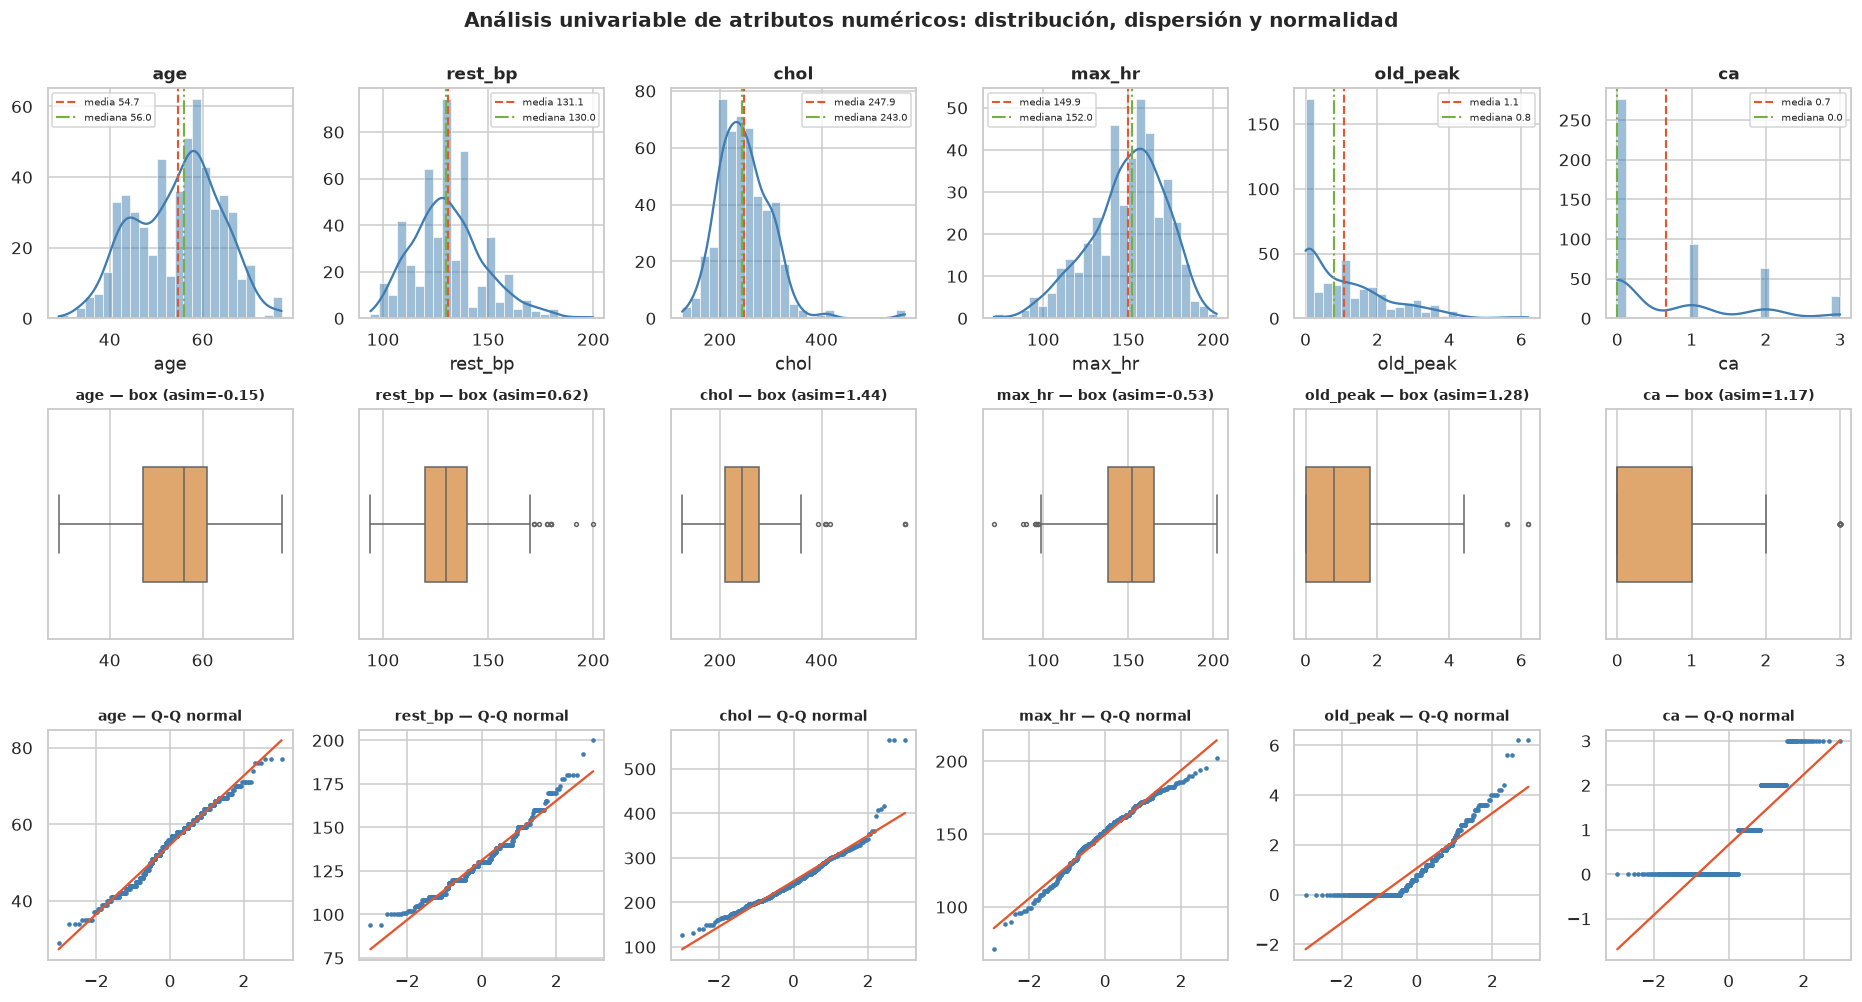

In [48]:
fig, axes = plt.subplots(3, 6, figsize=(17, 9))
for j, c in enumerate(NUM):
    x = pd.to_numeric(df_dedup[c].dropna(), errors='coerce').astype(float)

    # histograma + KDE
    ax = axes[0, j]
    sns.histplot(x, kde=True, ax=ax, color=PAL[0], bins=25, edgecolor='white', linewidth=.4)
    ax.axvline(x.mean(),   color=PAL[1], ls='--', lw=1.4, label=f'media {x.mean():.1f}')
    ax.axvline(x.median(), color=PAL[2], ls='-.', lw=1.4, label=f'mediana {x.median():.1f}')
    ax.set_title(c); ax.legend(fontsize=6.5); ax.set_ylabel('')

    # boxplot
    ax = axes[1, j]
    sns.boxplot(x=x, ax=ax, color=PAL[3], width=.5, fliersize=2.5)
    ax.set_title(f'{c} — box (asim={stats.skew(x):.2f})', fontsize=9); ax.set_xlabel('')

    # Q-Q plot
    ax = axes[2, j]
    stats.probplot(x, dist='norm', plot=ax)
    ax.get_lines()[0].set_markersize(2); ax.get_lines()[0].set_color(PAL[0])
    ax.get_lines()[1].set_color(PAL[1])
    ax.set_title(f'{c} — Q-Q normal', fontsize=9); ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('Análisis univariable de atributos numéricos: distribución, dispersión y normalidad',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(); plt.show()

#### Interpretación variable por variable

**`age` — Edad (años).**
Distribución **aproximadamente gaussiana**, ligeramente asimétrica a la izquierda (skew ≈ −0,2),
centrada en ~54 años y con recorrido 29–77. La curtosis negativa indica una forma algo más plana
que la normal (platicúrtica): la cohorte está concentrada en la franja 45–65 sin colas largas. No
hay outliers por Tukey. El test formal de normalidad la rechaza, pero eso es esperable con
n grande y una variable discretizada a años enteros; **a efectos prácticos es simétrica y no
necesita transformación**.
*Sesgo de selección a tener en cuenta:* no hay pacientes jóvenes, porque los datos proceden de
personas ya derivadas a una prueba de esfuerzo. El modelo no será válido en población general.

**`rest_bp` — Presión arterial en reposo (mm Hg).**
Media ≈ 132, mediana 130, **asimetría positiva moderada** (skew ≈ +0,7) con cola derecha de
pacientes hipertensos hasta 200 mm Hg. Se observa un patrón de **redondeo muy marcado**: los
valores se agolpan en múltiplos de 10 (120, 130, 140), un artefacto clásico de la lectura manual
de esfigmomanómetro. Esto significa que la **resolución real del atributo es de ±5 mm Hg**, no de
1 mm Hg: no tiene sentido tratarlo como una medida de alta precisión.

**`chol` — Colesterol total (mg/dl).**
La variable con **más asimetría positiva** (skew ≈ +1,1) y **curtosis alta** (leptocúrtica): pico
estrecho alrededor de 240 y cola derecha larga, con un máximo de **564 mg/dl**. Ese extremo es
un outlier estadístico pero **clínicamente plausible** (hipercolesterolemia familiar), así que
debe conservarse, no borrarse. El Q-Q plot confirma la desviación de la normalidad en la cola
superior. Es la candidata más clara a **transformación logarítmica**.

**`max_hr` — Frecuencia cardíaca máxima (lpm).**
**Asimetría negativa** (skew ≈ −0,5): cola hacia la izquierda formada por pacientes que no logran
elevar la frecuencia durante el esfuerzo — que es precisamente el grupo de interés clínico.
Recorrido 71–202 lpm. Existe una dependencia estructural conocida con la edad
(FC máxima teórica ≈ 220 − edad), que se explota en la sección multivariable.

**`old_peak` — Depresión del segmento ST.**
La distribución **más problemática** para un modelo lineal: fuertemente **asimétrica a la derecha**
(skew ≈ +1,2) y con una **masa de probabilidad concentrada en el cero** (el **32,7 %** de los
pacientes tiene exactamente 0,0; la mediana es 0,8 pero la moda es 0). No es una variable continua ordinaria sino una distribución
**semicontinua / *zero-inflated***: mezcla un proceso binario ("¿hay depresión ST?") con uno
continuo ("¿cuánta?"). Modelarla con una sola variable continua desaprovecha esa estructura;
la ingeniería de atributos propuesta la desdobla.

> **Nota sobre la tabla de outliers.** La regla de Tukey marca un 6 % de "atípicos" en `ca`, pero
> son simplemente los pacientes con `ca` = 3. **Tukey no es aplicable a una variable ordinal
> acotada de cuatro niveles**: el IQR degenera y el criterio pierde sentido. Los outliers
> realmente interpretables son los de `chol` (394–564 mg/dl), `rest_bp` (172–200 mm Hg) y
> `max_hr` (71–97 lpm), todos ellos **clínicamente plausibles**.

**`ca` — Nº de vasos afectados (0–3).**
Estrictamente es un **conteo ordinal**, no un continuo. Muy **asimétrica**: la mayoría de
pacientes tiene 0 vasos y la frecuencia decae rápidamente. Como se verá, es el predictor
individual más potente del conjunto.

### 6.3 Atributos categóricos

In [49]:
CAT = ['sex', 'chest_pain', 'rest_ecg', 'thal', 'fbs', 'exang', 'slope', 'disease']

for c in CAT:
    vc = df_dedup[c].value_counts(dropna=False)
    tabla = pd.DataFrame({'frecuencia': vc, 'pct': (vc/len(df_dedup)*100).round(2)})
    print(f'── {c} ({TIPOS[c][0]}) ' + '─'*(52-len(c)))
    print(tabla.to_string())
    print(f'   moda: {df_dedup[c].mode().iloc[0]}   |   '
          f'nulos: {df_dedup[c].isna().mean()*100:.2f}%   |   '
          f'entropía normalizada: {stats.entropy(vc.dropna())/np.log(vc.dropna().size):.3f}\n')

── sex (Categórico nominal binario) ─────────────────────────────────────────────────
        frecuencia    pct
sex                      
Male           367 64.730
Female         151 26.630
<NA>            49  8.640
   moda: Male   |   nulos: 8.64%   |   entropía normalizada: 0.770

── chest_pain (Categórico nominal (4 niveles)) ──────────────────────────────────────────
              frecuencia    pct
chest_pain                     
asymptomatic         231 40.740
nonanginal           148 26.100
nontypical            82 14.460
<NA>                  71 12.520
typical               35  6.170
   moda: asymptomatic   |   nulos: 12.52%   |   entropía normalizada: 0.887

── rest_ecg (Categórico nominal (3 niveles)) ────────────────────────────────────────────
                              frecuencia    pct
rest_ecg                                       
left ventricular hypertrophy         196 34.570
normal                               192 33.860
<NA>                                 174 30

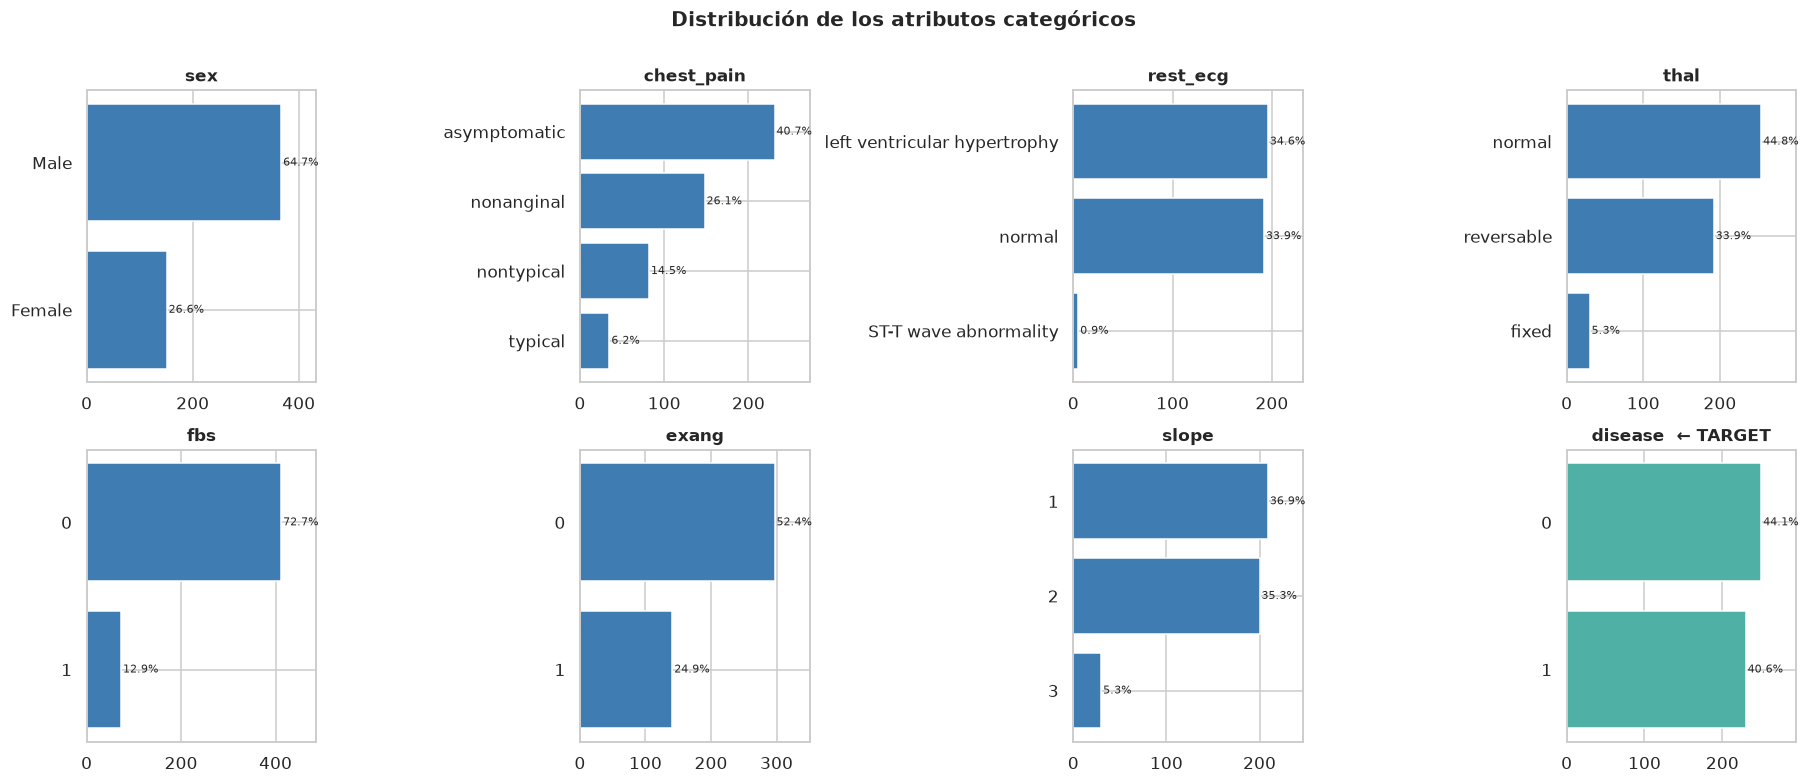

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(16.5, 7))
for ax, c in zip(axes.ravel(), CAT):
    vc = df_dedup[c].value_counts().sort_values(ascending=True)
    ax.barh([str(i) for i in vc.index], vc.values,
            color=PAL[5] if c == 'disease' else PAL[0])
    ax.set_title(f'{c}' + ('  ← TARGET' if c == 'disease' else ''))
    for i, v in enumerate(vc.values):
        ax.text(v + max(vc.values)*0.01, i, f'{v/len(df_dedup)*100:.1f}%',
                va='center', fontsize=7.5)
    ax.set_xlim(0, max(vc.values)*1.18)
plt.suptitle('Distribución de los atributos categóricos', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Lectura de los categóricos.**

- **`sex`** está muy **desbalanceado**: aproximadamente dos tercios de hombres. Cualquier métrica
  global del modelo estará dominada por el subgrupo masculino, y conviene evaluar el rendimiento
  **por sexo por separado** para no ocultar un peor comportamiento en mujeres (equidad del modelo).
- **`chest_pain`**: la categoría mayoritaria es `asymptomatic`, lo cual es contraintuitivo hasta
  que se recuerda el sesgo de derivación: los pacientes asintomáticos que llegan a una prueba de
  esfuerzo son, con frecuencia, los que ya tienen sospecha por otra vía.
- **`fbs`** es la variable más desbalanceada del conjunto (~85 % en la clase 0). Con esa
  distribución, su capacidad de discriminación es estructuralmente limitada.
- **`slope`** apenas registra la categoría 3 (descendente), que queda con muy pocos casos: es una
  **categoría rara** que puede provocar inestabilidad si se codifica *one-hot* sin agrupar.
- **`rest_ecg`** también tiene una categoría (`ST-T wave abnormality`) casi vacía → candidata a
  fusión con otra.

---
## 7. Identificación del atributo objetivo (target)

Se trata de un problema de **aprendizaje supervisado, clasificación binaria**.

**Target: `disease`** — 1 = presencia de enfermedad cardíaca, 0 = ausencia.

Distribución del target (df_dedup):
           n    pct
disease            
0        250 44.090
1        230 40.560
<NA>      87 15.340

Prevalencia de la clase positiva: 47.92%
Ratio de desbalance: 1.09 : 1
Baseline trivial (predecir siempre la clase mayoritaria): 52.08% de exactitud


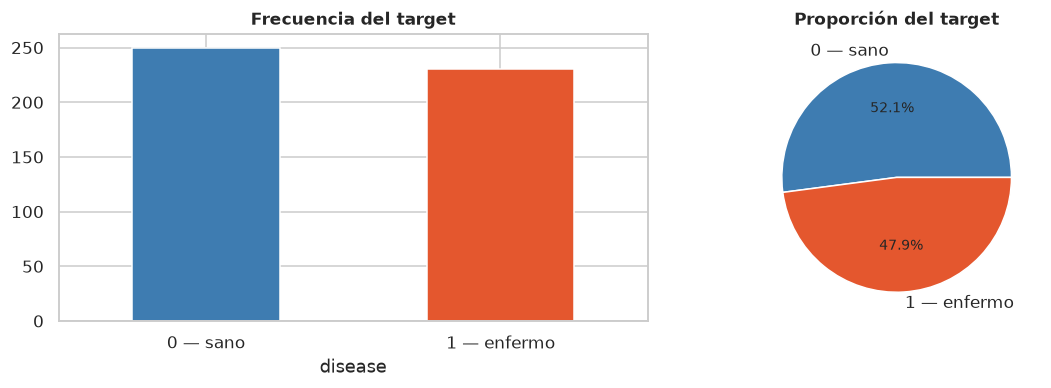

In [51]:
t = df_dedup['disease'].value_counts(dropna=False).sort_index()
print('Distribución del target (df_dedup):')
print(pd.DataFrame({'n': t, 'pct': (t/len(df_dedup)*100).round(2)}).to_string())

pos = df_dedup['disease'].mean()
print(f'\nPrevalencia de la clase positiva: {pos*100:.2f}%')
print(f'Ratio de desbalance: {(1-pos)/pos:.2f} : 1')
print(f'Baseline trivial (predecir siempre la clase mayoritaria): '
      f'{max(pos, 1-pos)*100:.2f}% de exactitud')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df_dedup['disease'].value_counts().sort_index().plot(
    kind='bar', ax=ax[0], color=[PAL[0], PAL[1]], rot=0)
ax[0].set_title('Frecuencia del target'); ax[0].set_xticklabels(['0 — sano', '1 — enfermo'])
df_dedup['disease'].value_counts().sort_index().plot(
    kind='pie', ax=ax[1], colors=[PAL[0], PAL[1]], autopct='%1.1f%%',
    labels=['0 — sano', '1 — enfermo'], ylabel='')
ax[1].set_title('Proporción del target')
plt.tight_layout(); plt.show()

**Consideraciones sobre el target.**

1. **El desbalance es leve** (≈ 48 % positivos frente a 52 % negativos sobre las filas únicas con
   etiqueta válida; el baseline trivial queda en ~52–54 % según la vista). No hace falta SMOTE ni
   sobremuestreo: basta con
   `class_weight='balanced'` si acaso, y con elegir bien la métrica.
2. **La métrica no debe ser la exactitud.** En un contexto clínico los errores no son simétricos:
   un **falso negativo** (dar de alta a un paciente enfermo) es mucho más grave que un **falso
   positivo** (someter a más pruebas a un paciente sano). La métrica principal debe ser el
   **recall de la clase positiva** o el **F2-score**, con el **AUC-ROC / AUC-PR** como métrica de
   ranking y el umbral de decisión ajustado explícitamente a favor de la sensibilidad.
3. **El target también está contaminado** (`fsg`, `gsfdg`, …) y tiene un **3,5 % de nulos sobre el
   fichero completo**, que sube al **15 % sobre las filas únicas** — porque la deduplicación
   elimina sobre todo copias intactas y concentra las corrompidas. Las filas
   sin target válido **no pueden imputarse**: imputar la etiqueta es inventarse la verdad. Deben
   apartarse del conjunto supervisado (podrían usarse, si acaso, en aprendizaje semi-supervisado).

---
## 8. Reglas de validación de datos

Estas reglas son un **entregable reutilizable**: constituyen el contrato de calidad que debe
aplicarse en la ingesta, antes de cualquier entrenamiento o inferencia. Se agrupan en cuatro
niveles: esquema, dominio, rango fisiológico y coherencia entre atributos.

In [52]:
REGLAS = [
 # nivel, atributo, regla, acción ante incumplimiento, severidad
 ('Esquema','*','El fichero debe tener exactamente 14 columnas con los nombres esperados','Rechazar el lote','Crítica'),
 ('Esquema','*','Toda celda de texto se normaliza: strip() de espacios y colapso de espacios internos','Corregir automáticamente','Info'),
 ('Esquema','*','Se rechaza la fila si TODOS sus campos son nulos','Descartar la fila','Crítica'),

 ('Dominio','sex','∈ {Male, Female}','→ NaN','Alta'),
 ('Dominio','chest_pain','∈ {typical, nontypical, nonanginal, asymptomatic}','→ NaN','Alta'),
 ('Dominio','rest_ecg','∈ {normal, ST-T wave abnormality, left ventricular hypertrophy}','→ NaN','Alta'),
 ('Dominio','thal','∈ {normal, fixed, reversable}','→ NaN','Alta'),
 ('Dominio','fbs','∈ {0, 1}','→ NaN','Alta'),
 ('Dominio','exang','∈ {0, 1}','→ NaN','Alta'),
 ('Dominio','slope','∈ {1, 2, 3} (entero ordinal)','→ NaN','Alta'),
 ('Dominio','ca','entero ∈ {0, 1, 2, 3}','→ NaN','Alta'),
 ('Dominio','disease','∈ {0, 1}','Descartar la fila del set supervisado','Crítica'),

 ('Rango','age','entero, 18 ≤ age ≤ 100','→ NaN','Alta'),
 ('Rango','rest_bp','entero, 70 ≤ rest_bp ≤ 250 mm Hg','→ NaN','Alta'),
 ('Rango','chol','entero, 80 ≤ chol ≤ 700 mg/dl','→ NaN','Alta'),
 ('Rango','max_hr','entero, 50 ≤ max_hr ≤ 230 lpm','→ NaN','Alta'),
 ('Rango','old_peak','float, 0.0 ≤ old_peak ≤ 10.0 (nunca negativo)','→ NaN','Alta'),

 ('Alerta','chol','chol > 500 mg/dl: extremo pero posible','Marcar para revisión, NO borrar','Media'),
 ('Alerta','rest_bp','rest_bp > 200 mm Hg: crisis hipertensiva','Marcar para revisión','Media'),
 ('Alerta','max_hr','max_hr > 220 − age + 15','Marcar: incoherencia fisiológica','Media'),
 ('Alerta','chol','chol == 0 se usa como código de "no medido" en otras versiones del dataset','Tratar como faltante, no como cero','Alta'),

 ('Coherencia','max_hr/age','max_hr no debería superar de forma sistemática 220 − age','Marcar','Media'),
 ('Coherencia','old_peak/slope','old_peak = 0 es incompatible con slope = 3 (descendente marcado)','Marcar','Baja'),
 ('Coherencia','exang/chest_pain','exang = 1 con chest_pain = asymptomatic es poco frecuente','Marcar','Baja'),

 ('Volumen','*','% de nulos por columna ≤ 10 % en el lote','Alertar al equipo de datos','Media'),
 ('Volumen','*','% de valores fuera de dominio por columna ≤ 1 %','Alertar: posible cambio de esquema en origen','Alta'),
 ('Volumen','*','% de filas duplicadas exactas ≤ 5 %','Alertar: posible reproceso o carga repetida','Alta'),
 ('Deriva','*','La media de cada numérica no debe alejarse > 3σ de la del set de referencia','Alertar: data drift','Media'),
]
reglas_df = pd.DataFrame(REGLAS, columns=['nivel','atributo','regla','acción','severidad'])
reglas_df

,nivel,atributo,regla,acción,severidad
0,Esquema,*,El fichero debe tener exactamente 14 columnas ...,Rechazar el lote,Crítica
1,Esquema,*,Toda celda de texto se normaliza: strip() de e...,Corregir automáticamente,Info
2,Esquema,*,Se rechaza la fila si TODOS sus campos son nulos,Descartar la fila,Crítica
3,Dominio,sex,"∈ {Male, Female}",→ NaN,Alta
4,Dominio,chest_pain,"∈ {typical, nontypical, nonanginal, asymptomatic}",→ NaN,Alta
5,Dominio,rest_ecg,"∈ {normal, ST-T wave abnormality, left ventric...",→ NaN,Alta
6,Dominio,thal,"∈ {normal, fixed, reversable}",→ NaN,Alta
7,Dominio,fbs,"∈ {0, 1}",→ NaN,Alta
8,Dominio,exang,"∈ {0, 1}",→ NaN,Alta
9,Dominio,slope,"∈ {1, 2, 3} (entero ordinal)",→ NaN,Alta


In [53]:
def validar(df_texto, reglas_verbose=True):
    """Aplica las reglas de validación y devuelve (df_tipado, informe_de_incidencias)."""
    inc = []
    n0 = len(df_texto)

    vacias = df_texto.isna().all(axis=1).sum()
    inc.append(('Esquema', '*', 'filas completamente vacías', vacias))

    dups = df_texto.duplicated().sum()
    inc.append(('Volumen', '*', 'filas duplicadas exactas', dups))

    for c in df_texto.columns:
        s = normaliza(df_texto[c])
        inc.append(('Esquema', c, 'valores nulos', int(s.isna().sum())))
        if c in CATEGORICAS_VALIDAS:
            n = int((s.notna() & ~s.isin(CATEGORICAS_VALIDAS[c])).sum())
        else:
            n = int((s.notna() & pd.to_numeric(s, errors='coerce').isna()).sum())
        inc.append(('Dominio', c, 'fuera de dominio', n))

    tip = construir_tipado(df_texto)
    for c in NUMERICAS:
        perdidos = int((tip[c].isna() & df_texto[c].notna()).sum())
        inc.append(('Rango', c, 'fuera de rango o no parseable', perdidos))

    # coherencia fisiológica
    incoh = int((tip['max_hr'] > (220 - tip['age'] + 15)).sum())
    inc.append(('Coherencia', 'max_hr/age', 'max_hr > 220-age+15', incoh))

    rep = (pd.DataFrame(inc, columns=['nivel','atributo','incidencia','n'])
             .query('n > 0')
             .assign(pct=lambda d: (d['n']/n0*100).round(2))
             .sort_values(['nivel','n'], ascending=[True, False]))
    return tip, rep

_, informe_val = validar(raw)
print(f'INFORME DE VALIDACIÓN — {len(raw):,} filas de entrada\n' + '='*70)
informe_val.to_string(index=False)
display(informe_val)

INFORME DE VALIDACIÓN — 3,030 filas de entrada


,nivel,atributo,incidencia,n,pct
35,Coherencia,max_hr/age,max_hr > 220-age+15,95,3.140
15,Dominio,rest_ecg,fuera de dominio,5,0.170
29,Dominio,disease,fuera de dominio,5,0.170
27,Dominio,thal,fuera de dominio,4,0.130
5,Dominio,sex,fuera de dominio,3,0.100
7,Dominio,chest_pain,fuera de dominio,3,0.100
3,Dominio,age,fuera de dominio,2,0.070
9,Dominio,rest_bp,fuera de dominio,2,0.070
11,Dominio,chol,fuera de dominio,2,0.070
19,Dominio,exang,fuera de dominio,2,0.070


Este informe es exactamente lo que un pipeline de producción debería emitir en cada carga.
Los umbrales de la sección *Volumen* actuarían como semáforo. Con un **81,3 % de filas
duplicadas** frente a un límite del 5 %, **este lote no pasaría la validación** y debería
devolverse al origen antes de entrenar nada. El porcentaje de nulos (1–6 % por columna) queda
dentro de tolerancia, y los valores fuera de dominio son pocos en volumen (**33 celdas, 0,08 %**)
pero **cualitativamente graves**, porque bastan para corromper silenciosamente el encoding de una
categórica.

---
## 9. Análisis bivariable

Se estudian las relaciones **entre pares de atributos**, con especial atención a la relación de
cada predictor con el target.

### 9.1 Numéricas frente al target

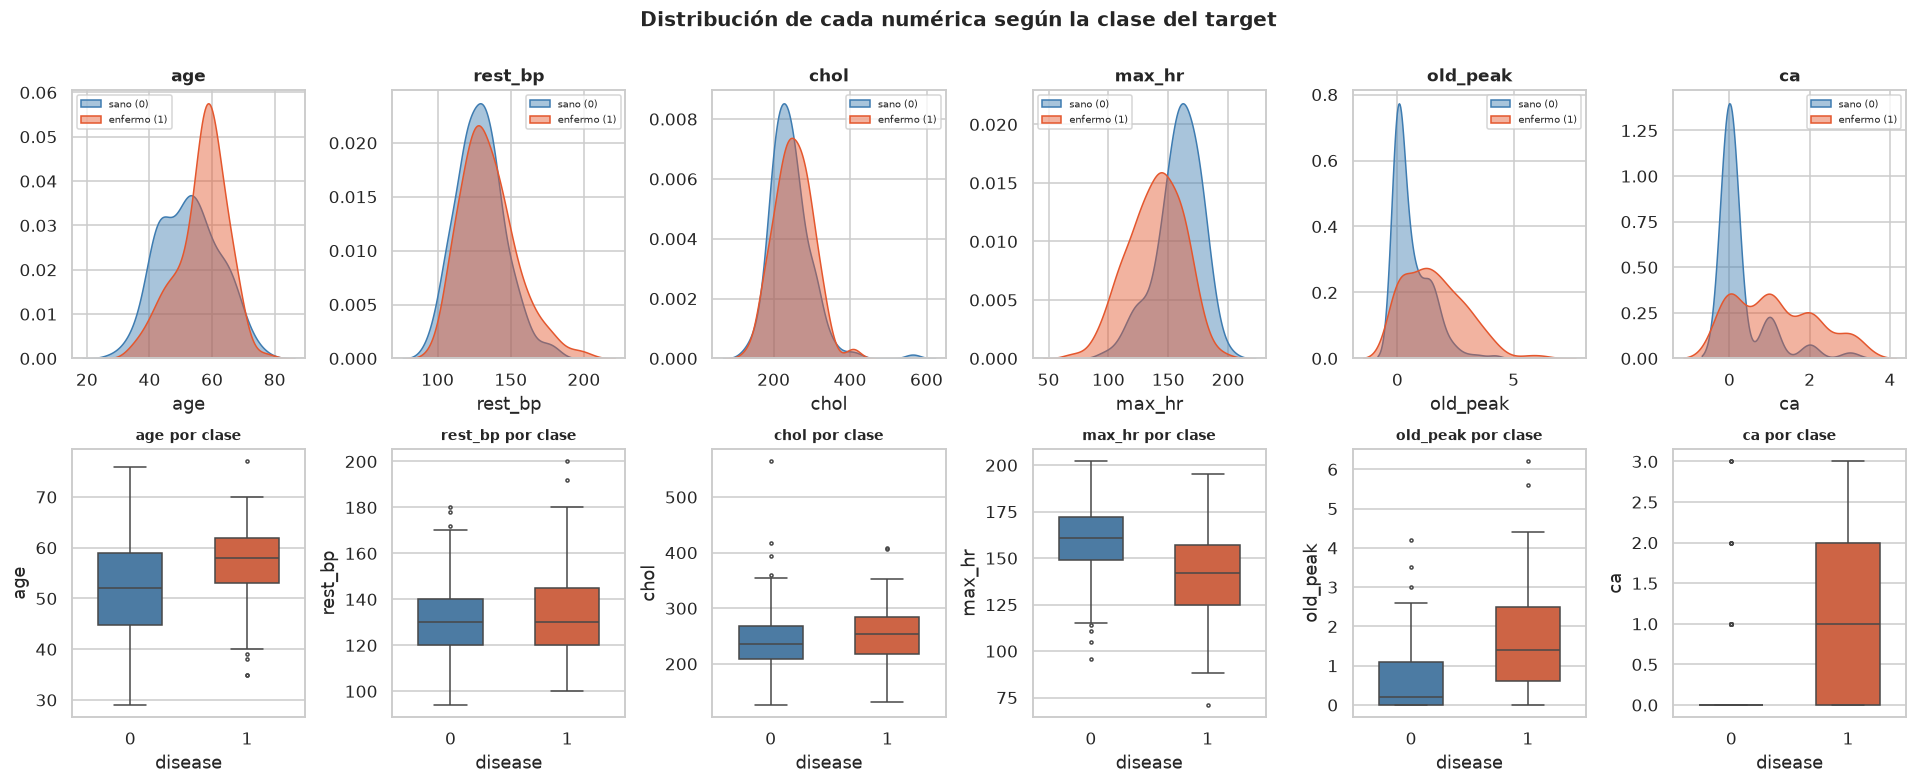

,atributo,media_sano,media_enfermo,dif,d_Cohen,p_ttest,p_MannWhitney,magnitud
5,ca,0.275,1.146,0.871,1.027,0.000,0.000,grande
3,max_hr,158.581,139.109,-19.472,-0.929,0.000,0.000,grande
4,old_peak,0.599,1.589,0.990,0.919,0.000,0.000,grande
0,age,52.644,56.759,4.115,0.470,0.000,0.000,pequeño
1,rest_bp,129.175,134.635,5.460,0.309,0.009,0.024,pequeño
2,chol,243.494,251.854,8.360,0.162,0.165,0.047,despreciable


In [54]:
fig, axes = plt.subplots(2, 6, figsize=(17.5, 7))
res_biv = []
for j, c in enumerate(NUM):
    d = df_limpio[[c, 'disease']].dropna()
    g0 = d.loc[d.disease == 0, c].astype(float)
    g1 = d.loc[d.disease == 1, c].astype(float)

    sns.kdeplot(g0, ax=axes[0, j], fill=True, color=PAL[0], label='sano (0)', alpha=.45)
    sns.kdeplot(g1, ax=axes[0, j], fill=True, color=PAL[1], label='enfermo (1)', alpha=.45)
    axes[0, j].set_title(c); axes[0, j].legend(fontsize=6.5); axes[0, j].set_ylabel('')

    sns.boxplot(data=d, x='disease', y=c, ax=axes[1, j],
                palette=[PAL[0], PAL[1]], width=.55, fliersize=2)
    axes[1, j].set_title(f'{c} por clase', fontsize=9); axes[1, j].set_xlabel('disease')

    t_st, p = stats.ttest_ind(g0, g1, equal_var=False)
    u_st, pu = stats.mannwhitneyu(g0, g1)
    pooled = np.sqrt((g0.var() + g1.var()) / 2)
    d_cohen = (g1.mean() - g0.mean()) / pooled
    res_biv.append({'atributo': c, 'media_sano': g0.mean(), 'media_enfermo': g1.mean(),
                    'dif': g1.mean()-g0.mean(), 'd_Cohen': d_cohen,
                    'p_ttest': p, 'p_MannWhitney': pu})

plt.suptitle('Distribución de cada numérica según la clase del target',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

biv = pd.DataFrame(res_biv).assign(
    magnitud=lambda d: pd.cut(d.d_Cohen.abs(), [0,.2,.5,.8,np.inf],
                              labels=['despreciable','pequeño','mediano','grande'])
).sort_values('d_Cohen', key=abs, ascending=False)
biv.round(4)

**Lectura.** Ordenadas por tamaño del efecto (d de Cohen, que es independiente del tamaño
muestral y por tanto **inmune al inflado por replicación** — a diferencia de los *p*-valores, que
aquí son irrealmente pequeños):

- **`ca`** (d ≈ 1,03) y **`old_peak`** (d ≈ 0,92) muestran los efectos más grandes: los pacientes
  enfermos tienen más vasos afectados y mayor depresión del ST.
- **`max_hr`** presenta un efecto grande **negativo**: los enfermos alcanzan una frecuencia
  cardíaca máxima claramente menor. Es un hallazgo con sentido fisiológico directo
  (incompetencia cronotrópica).
- **`age`** queda justo en la frontera entre efecto pequeño y mediano (d ≈ 0,47) y **`rest_bp`**
  es claramente pequeño (d ≈ 0,31).
- **`chol`** resulta **prácticamente inútil por sí solo** en esta cohorte: d ≈ 0,16 y la
  diferencia de medias **ni siquiera alcanza significación** (p ≈ 0,17 en el test t), pese al
  tamaño muestral inflado. Las distribuciones de sanos y enfermos se solapan casi por completo. Es un resultado contraintuitivo pero bien
  documentado en este dataset, y un buen recordatorio de que "factor de riesgo conocido" no
  equivale a "predictor útil en esta muestra".

### 9.2 Categóricas frente al target

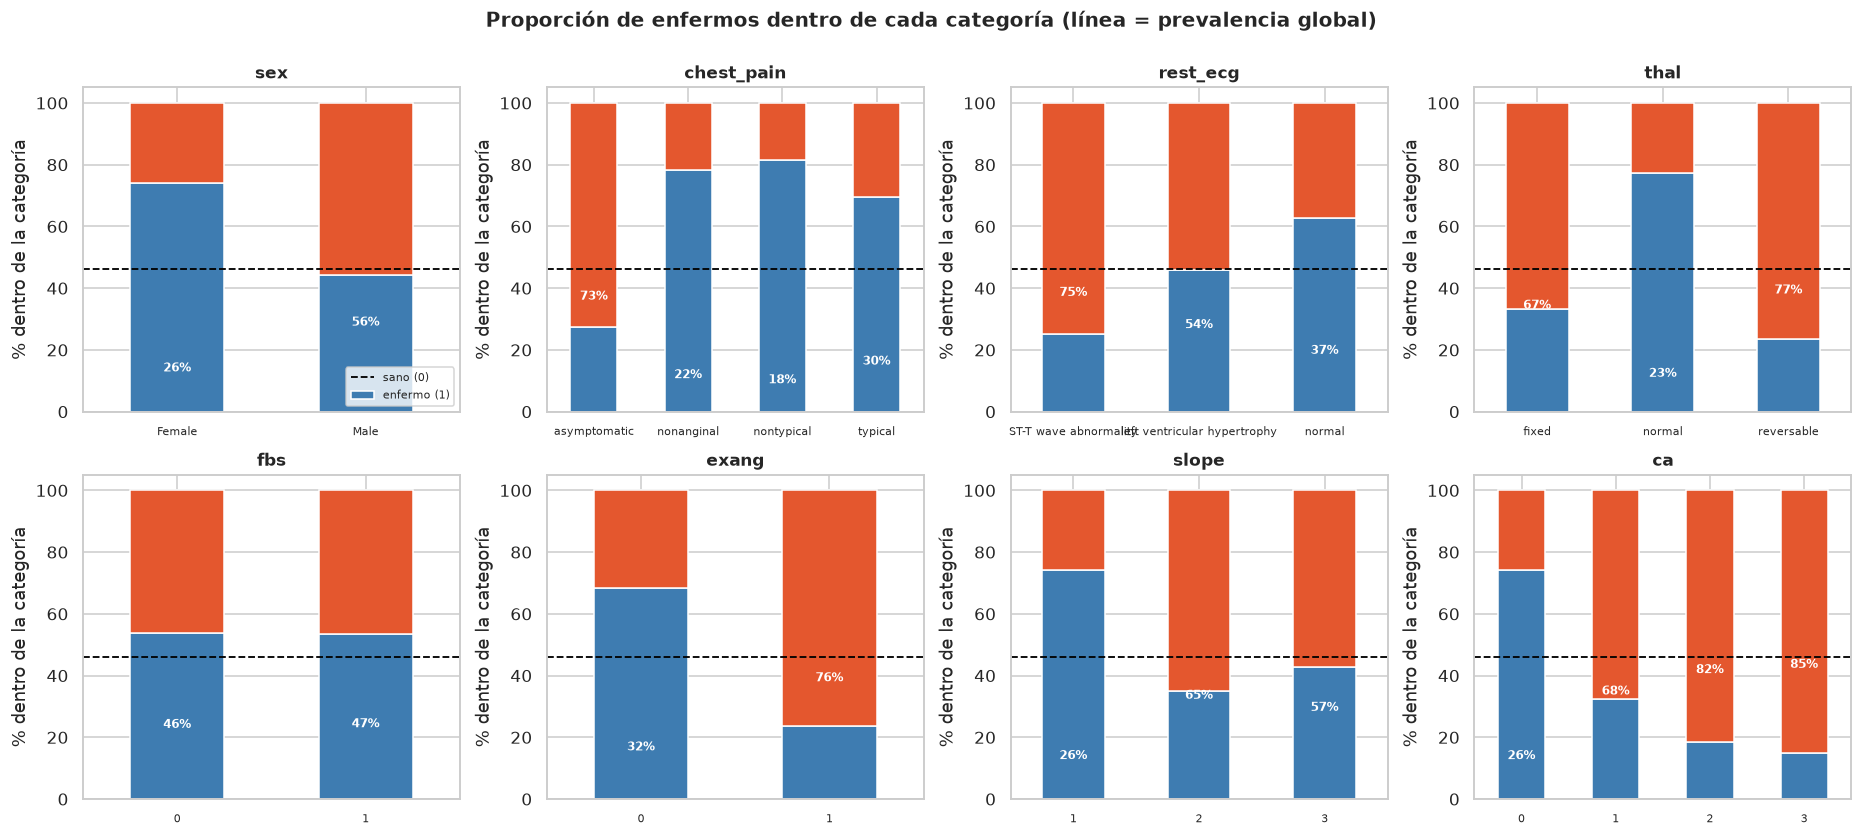

,atributo,chi2,gl,p_valor,V_Cramer,rango_%enfermos,fuerza
3,thal,82.460,2,0.000,0.527,23% – 77%,fuerte
1,chest_pain,77.276,3,0.000,0.510,18% – 73%,fuerte
7,ca,72.300,3,0.000,0.493,26% – 85%,moderada
5,exang,50.943,1,0.000,0.414,32% – 76%,moderada
6,slope,43.473,2,0.000,0.383,26% – 65%,moderada
0,sex,21.852,1,0.000,0.271,26% – 56%,débil
2,rest_ecg,9.575,2,0.008,0.180,37% – 75%,débil
4,fbs,0.000,1,1.000,0.000,46% – 47%,NaN


In [55]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.5))
res_cat = []
for ax, c in zip(axes.ravel(), [x for x in CAT if x != 'disease'] + ['ca']):
    d = df_limpio[[c, 'disease']].dropna()
    ct = pd.crosstab(d[c], d['disease'])
    ctn = ct.div(ct.sum(axis=1), axis=0) * 100
    ctn.plot(kind='bar', stacked=True, ax=ax, color=[PAL[0], PAL[1]], rot=0, legend=False)
    ax.axhline(df_limpio['disease'].mean()*100, color='black', ls='--', lw=1.2)
    ax.set_title(c); ax.set_ylabel('% dentro de la categoría'); ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7.5)
    for i, (idx, row) in enumerate(ctn.iterrows()):
        ax.text(i, row[1]/2, f'{row[1]:.0f}%', ha='center', color='white',
                fontweight='bold', fontsize=8)

    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramer = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    res_cat.append({'atributo': c, 'chi2': chi2, 'gl': dof, 'p_valor': p,
                    'V_Cramer': cramer,
                    'rango_%enfermos': f'{ctn[1].min():.0f}% – {ctn[1].max():.0f}%'})

axes.ravel()[0].legend(['sano (0)', 'enfermo (1)'], fontsize=7.5, loc='lower right')
plt.suptitle('Proporción de enfermos dentro de cada categoría (línea = prevalencia global)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(); plt.show()

cat_stats = (pd.DataFrame(res_cat)
             .assign(fuerza=lambda d: pd.cut(d.V_Cramer, [0,.1,.3,.5,1],
                     labels=['despreciable','débil','moderada','fuerte']))
             .sort_values('V_Cramer', ascending=False))
cat_stats.round(4)

**Lectura.** La **V de Cramér** mide la fuerza de asociación entre dos categóricas en la escala
0–1 y, al igual que la d de Cohen, no depende del tamaño muestral. El orden resultante es:

1. **`thal`** — un defecto de perfusión `reversable` dispara la proporción de enfermos.
2. **`chest_pain`** (V ≈ 0,51) — llamativamente, la categoría `asymptomatic` es la de mayor
   proporción de enfermos, con un 73 % (de nuevo, el sesgo de derivación de la cohorte).
3. **`ca`** (V ≈ 0,49) — con 0 vasos afectados la enfermedad es minoritaria (26 %); con 3 vasos
   alcanza el 85 %. Es un **escalón muy nítido**, y por eso es la base natural de la heurística.
4. **`exang`** y **`slope`** — asociación moderada y coherente con la fisiología.
5. **`sex`** — asociación moderada: mayor prevalencia en hombres.
6. **`rest_ecg`** — asociación débil (V ≈ 0,18), y **`fbs`** con **V = 0,000**: la proporción de
   enfermos es idéntica (46 % frente a 47 %) tenga el paciente la glucemia alta o no. Es, a todos
   los efectos, **una variable sin información** en esta cohorte.

### 9.3 Relaciones entre predictores (sin el target)

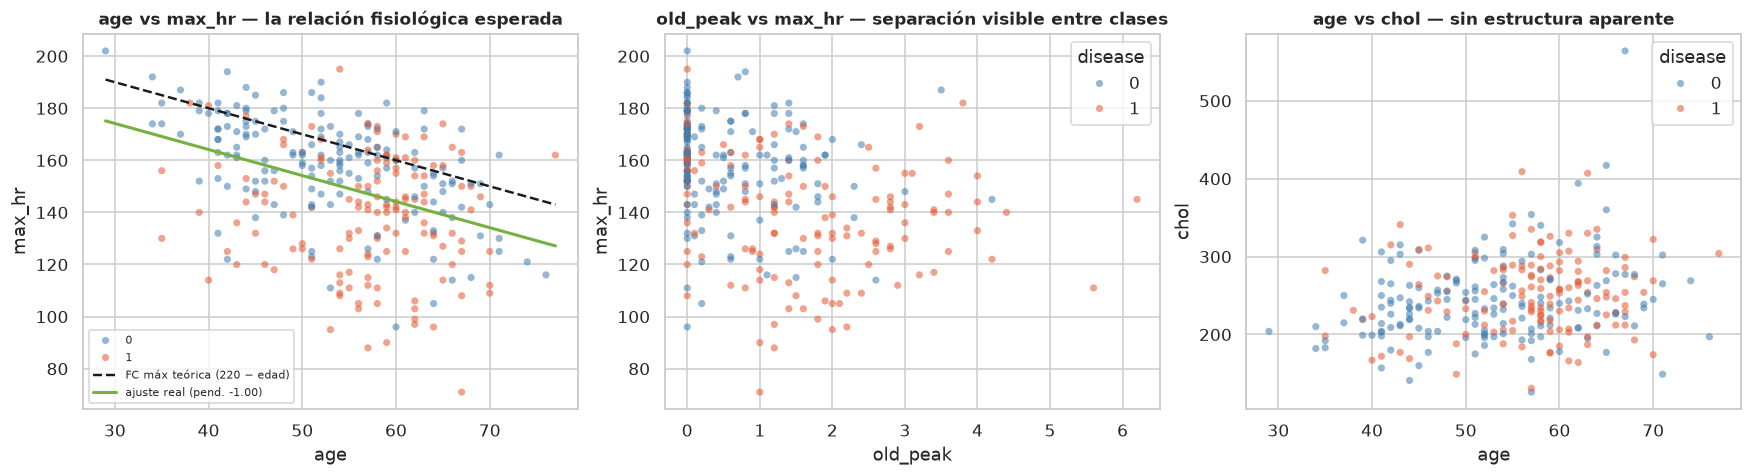

Correlación age–max_hr : r = -0.395
Pendiente observada    : -1.000 lpm por año (teórica esperada: −1.00)


In [56]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

d = df_limpio.dropna(subset=['age', 'max_hr'])
sns.scatterplot(data=d, x='age', y='max_hr', hue='disease', ax=ax[0],
                palette=[PAL[0], PAL[1]], alpha=.55, s=22, edgecolor='none')
xx = np.linspace(d.age.astype(float).min(), d.age.astype(float).max(), 50)
ax[0].plot(xx, 220 - xx, 'k--', lw=1.6, label='FC máx teórica (220 − edad)')
m, b = np.polyfit(d.age.astype(float), d.max_hr.astype(float), 1)
ax[0].plot(xx, m*xx + b, color=PAL[2], lw=2, label=f'ajuste real (pend. {m:.2f})')
ax[0].set_title('age vs max_hr — la relación fisiológica esperada'); ax[0].legend(fontsize=7.5)

sns.scatterplot(data=df_limpio, x='old_peak', y='max_hr', hue='disease', ax=ax[1],
                palette=[PAL[0], PAL[1]], alpha=.55, s=22, edgecolor='none')
ax[1].set_title('old_peak vs max_hr — separación visible entre clases')

sns.scatterplot(data=df_limpio, x='age', y='chol', hue='disease', ax=ax[2],
                palette=[PAL[0], PAL[1]], alpha=.55, s=22, edgecolor='none')
ax[2].set_title('age vs chol — sin estructura aparente')
plt.tight_layout(); plt.show()

r_am = stats.pearsonr(d.age.astype(float), d.max_hr.astype(float))
print(f'Correlación age–max_hr : r = {r_am[0]:.3f}')
print(f'Pendiente observada    : {m:.3f} lpm por año (teórica esperada: −1.00)')

La relación **`age` – `max_hr`** merece un comentario aparte porque es la única dependencia
estructural fuerte del conjunto (r = −0,395). La fórmula clínica clásica dice que la frecuencia cardíaca máxima
teórica es `220 − edad`; los datos reproducen esa tendencia decreciente pero con una pendiente
más suave y con una nube de puntos que cae sistemáticamente **por debajo** de la recta teórica.
Lo notable es que la **pendiente ajustada es −0,995 lpm por año**, prácticamente idéntica a la
teórica de −1, pero con una **ordenada en el origen de ~204 en lugar de 220**: la nube reproduce
la ley fisiológica desplazada unos 16 lpm **por debajo** de lo esperado, que es lo propio de una
cohorte de pacientes cardiológicos.

Esa distancia a la recta —cuánto se queda el paciente por debajo de lo que le corresponde por
edad— es una **variable derivada con sentido clínico propio**, y es una de las mejores candidatas
de la ingeniería de atributos.

### 9.4 Matriz de correlaciones

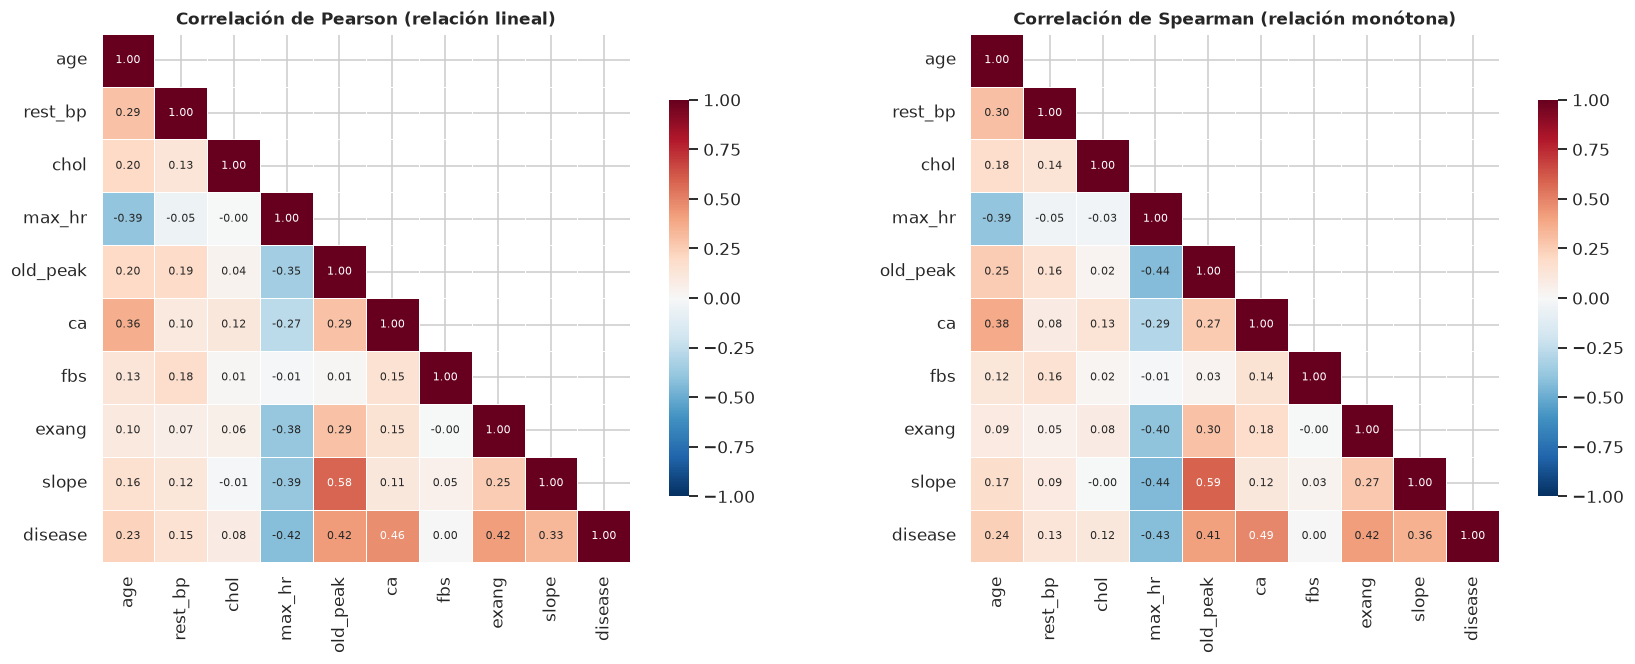

Correlación de cada atributo con el target (ordenada):
ca          0.463
old_peak    0.424
max_hr     -0.424
exang       0.421
slope       0.333
age         0.227
rest_bp     0.153
chol        0.080
fbs         0.003


In [57]:
num_para_corr = df_limpio[NUM + ['fbs','exang','slope','disease']].astype(float)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for a, metodo, titulo in zip(ax, ['pearson','spearman'],
                             ['Pearson (relación lineal)','Spearman (relación monótona)']):
    corr = num_para_corr.corr(method=metodo)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, ax=a, annot_kws={'size': 7.5},
                cbar_kws={'shrink': .75}, linewidths=.4)
    a.set_title(f'Correlación de {titulo}')
plt.tight_layout(); plt.show()

print('Correlación de cada atributo con el target (ordenada):')
print(num_para_corr.corr()['disease'].drop('disease')
      .sort_values(key=abs, ascending=False).round(3).to_string())

**Puntos a destacar:**

- **No hay multicolinealidad preocupante** entre predictores: la correlación más alta entre dos
  predictores es `age`–`max_hr` (≈ −0,39), muy lejos de un nivel problemático. Esto es una buena
  noticia: los atributos aportan información **complementaria**, no redundante, y no hace falta
  eliminar variables por redundancia.
- Pearson y Spearman dan órdenes muy parecidos, lo que indica que las relaciones son
  **monótonas y aproximadamente lineales**; no hay relaciones en forma de U escondidas.
- Ninguna correlación individual con el target supera ~0,45 en valor absoluto. **Ningún atributo
  resuelve el problema por sí solo**: la señal está repartida, y es la combinación la que
  discrimina. Esto anticipa que una heurística de una sola regla tendrá un techo bajo.

---
## 10. Análisis multivariable

Se estudia el comportamiento **conjunto** de varios atributos.

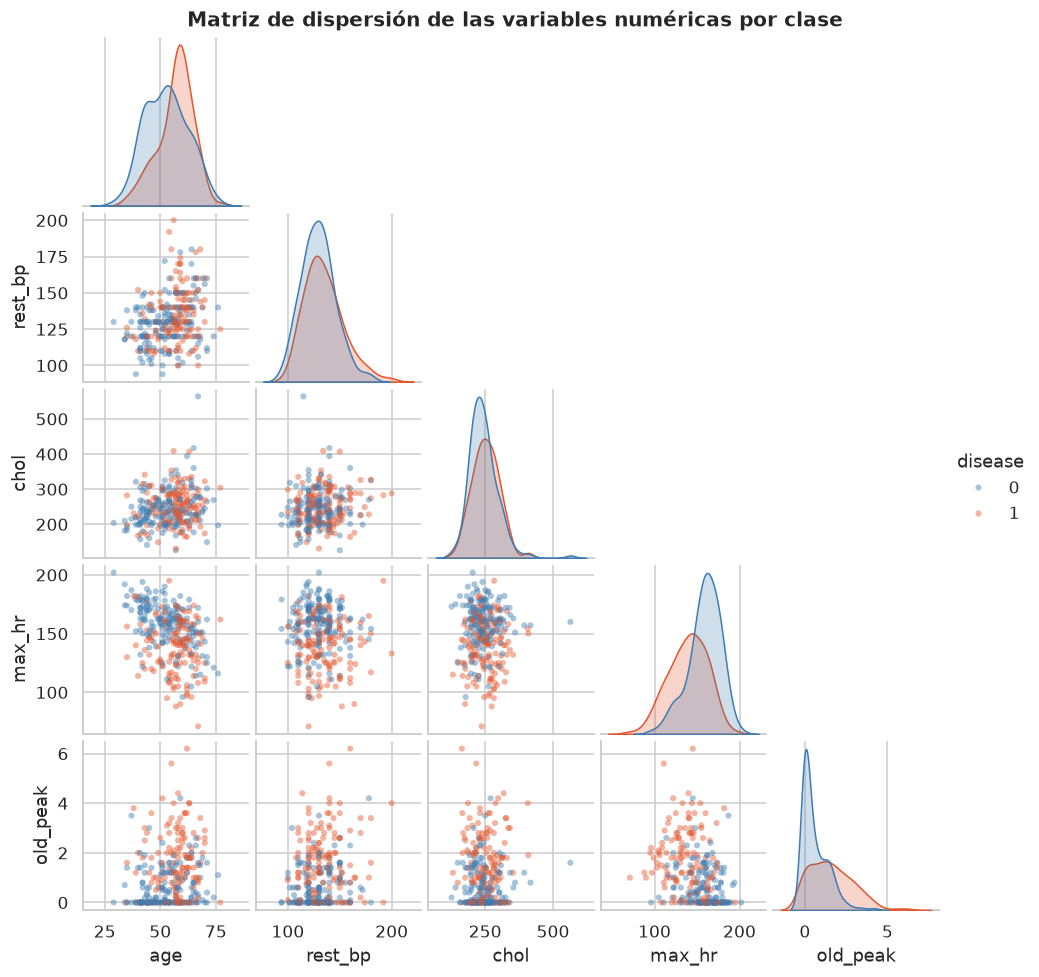

In [58]:
sub = df_limpio[['age','rest_bp','chol','max_hr','old_peak','disease']].dropna().astype(float)
sub['disease'] = sub['disease'].astype(int)
g = sns.pairplot(sub, hue='disease', palette=[PAL[0], PAL[1]],
                 corner=True, diag_kind='kde',
                 plot_kws={'alpha':.45, 's':16, 'edgecolor':'none'},
                 height=1.75)
g.fig.suptitle('Matriz de dispersión de las variables numéricas por clase',
               y=1.01, fontsize=13, fontweight='bold')
plt.show()

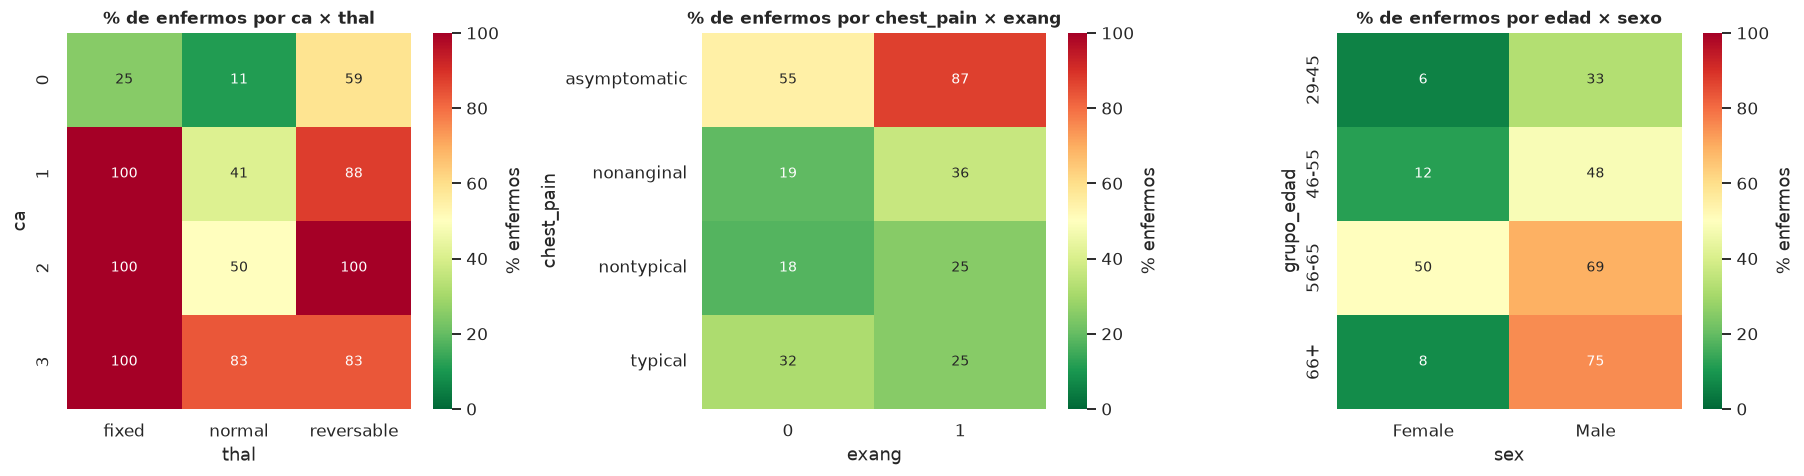

In [59]:
# Cómo interactúan tres atributos a la vez sobre la probabilidad de enfermedad
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4))

piv = df_limpio.pivot_table(index='ca', columns='thal', values='disease',
                            aggfunc='mean', observed=True).astype(float) * 100
sns.heatmap(piv, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=100,
            ax=ax[0], cbar_kws={'label': '% enfermos'})
ax[0].set_title('% de enfermos por ca × thal')

piv2 = df_limpio.pivot_table(index='chest_pain', columns='exang', values='disease',
                             aggfunc='mean', observed=True).astype(float) * 100
sns.heatmap(piv2, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=100,
            ax=ax[1], cbar_kws={'label': '% enfermos'})
ax[1].set_title('% de enfermos por chest_pain × exang')

df_tmp = df_limpio.copy()
df_tmp['grupo_edad'] = pd.cut(df_tmp['age'].astype(float),
                              [28, 45, 55, 65, 80], labels=['29-45','46-55','56-65','66+'])
piv3 = df_tmp.pivot_table(index='grupo_edad', columns='sex', values='disease',
                          aggfunc='mean', observed=True).astype(float) * 100
sns.heatmap(piv3, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=100,
            ax=ax[2], cbar_kws={'label': '% enfermos'})
ax[2].set_title('% de enfermos por edad × sexo')
plt.tight_layout(); plt.show()

Estos mapas de calor revelan **interacciones** que el análisis bivariable no puede ver. La más
llamativa es `ca × thal`: un paciente con **0 vasos y `thal` normal** tiene una probabilidad de
enfermedad muy baja, mientras que **≥ 1 vaso y `thal` reversible** la lleva por encima del 80 %.
El efecto conjunto es **más que la suma de los efectos por separado**, lo que sugiere que un
modelo capaz de capturar interacciones (árboles, *gradient boosting*) tendrá ventaja sobre una
regresión logística sin términos de interacción explícitos.

El mapa `edad × sexo` muestra otro matiz: la prevalencia crece con la edad en ambos sexos, pero
el nivel de partida es muy distinto — el riesgo de una mujer de 66+ es comparable al de un hombre
bastante más joven.

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_num = df_limpio[NUM].dropna().astype(float)
y_num = df_limpio.loc[X_num.index, 'disease'].astype(int)
Xs = StandardScaler().fit_transform(X_num)

pca = PCA().fit(Xs)
Z = pca.transform(Xs)

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4))
ax[0].plot(range(1, len(pca.explained_variance_ratio_)+1),
           np.cumsum(pca.explained_variance_ratio_)*100, 'o-', color=PAL[0])
ax[0].axhline(90, color=PAL[1], ls='--', label='90 % de varianza')
ax[0].set_xlabel('nº de componentes'); ax[0].set_ylabel('% varianza acumulada')
ax[0].set_title('PCA — varianza explicada acumulada'); ax[0].legend(fontsize=8)

for cl, col, lab in [(0, PAL[0], 'sano'), (1, PAL[1], 'enfermo')]:
    m = y_num.values == cl
    ax[1].scatter(Z[m, 0], Z[m, 1], s=18, alpha=.5, color=col, label=lab, edgecolor='none')
ax[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax[1].set_title('Proyección PCA (solo numéricas)'); ax[1].legend(fontsize=8)

carga = pd.DataFrame(pca.components_[:2].T, index=NUM, columns=['PC1','PC2'])
sns.heatmap(carga, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax[2],
            cbar_kws={'shrink': .8})
ax[2].set_title('Cargas de las dos primeras componentes')
plt.tight_layout(); plt.show()

print('Varianza explicada por componente:',
      np.round(pca.explained_variance_ratio_*100, 2))

ModuleNotFoundError: No module named 'sklearn'

**Conclusión del PCA.** La varianza está **muy repartida**: la primera componente explica solo
un **34,6 %** y hacen falta **5 de las 6 componentes** para superar el 90 %. Dicho de otro modo, **no hay redundancia que comprimir** — cada variable
numérica aporta una dirección de información propia. En consecuencia:

- **PCA no es útil aquí como reducción de dimensionalidad.** Con 13 predictores y varias miles de
  filas no hay problema de dimensionalidad que resolver, y aplicarlo solo destruiría la
  interpretabilidad, que en un contexto clínico es un requisito, no un lujo.
- La proyección PC1–PC2 muestra las dos clases **solapadas pero con desplazamiento de sus
  centroides**: hay señal, pero **no separación lineal limpia** en el espacio de las numéricas.
  Confirma que la información categórica (`ca`, `thal`, `chest_pain`) es imprescindible.

---
## 11. Resolver el problema manualmente: modelo heurístico

El enunciado pide estudiar **cómo resolvería el problema una persona sin *machine learning***.
Esto cumple dos funciones: da un **suelo de rendimiento** contra el que medir cualquier modelo
posterior, y obliga a entender el problema en términos del dominio.

Se construyen y evalúan **cinco heurísticas de complejidad creciente**, todas ellas
verbalizables en una frase y aplicables a mano por un clínico.

In [ ]:
def evaluar(y_true, y_pred, nombre):
    y_true = np.asarray(y_true).astype(int); y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_pred==1) & (y_true==1)).sum()); tn = int(((y_pred==0) & (y_true==0)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum()); fn = int(((y_pred==0) & (y_true==1)).sum())
    acc  = (tp+tn)/len(y_true)
    prec = tp/(tp+fp) if tp+fp else 0
    rec  = tp/(tp+fn) if tp+fn else 0
    espec= tn/(tn+fp) if tn+fp else 0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
    f2   = 5*prec*rec/(4*prec+rec) if (4*prec+rec) else 0
    return {'heurística': nombre, 'exactitud': acc, 'precisión': prec, 'recall (sens.)': rec,
            'especificidad': espec, 'F1': f1, 'F2': f2, 'VP': tp, 'VN': tn, 'FP': fp, 'FN': fn}

H = df_limpio.copy()
y = H['disease'].astype(int)

resultados = []
predicciones = {}

# H0 — baseline trivial
p = np.full(len(H), int(y.mean() > .5)); predicciones['H0'] = p
resultados.append(evaluar(y, p, 'H0 · Predecir siempre la clase mayoritaria'))

# H1 — regla única sobre el mejor predictor
p = (H['ca'].astype(int) >= 1).astype(int); predicciones['H1'] = p
resultados.append(evaluar(y, p, 'H1 · ca ≥ 1  (un solo atributo)'))

# H2 — dos atributos clínicos
p = ((H['ca'].astype(int) >= 1) | (H['thal'].astype(str) == 'reversable')).astype(int)
predicciones['H2'] = p
resultados.append(evaluar(y, p, 'H2 · ca ≥ 1  O  thal = reversable'))

# H3 — sistema de puntuación clínica (score de 6 signos de alarma)
score = (
    (H['ca'].astype(int) >= 1).astype(int) +
    (H['thal'].astype(str) == 'reversable').astype(int) +
    (H['chest_pain'].astype(str) == 'asymptomatic').astype(int) +
    (H['exang'].astype(int) == 1).astype(int) +
    (H['old_peak'].astype(float) > 1.0).astype(int) +
    (H['slope'].astype(int) >= 2).astype(int)
)
H['score'] = score
p = (score >= 3).astype(int); predicciones['H3'] = p
resultados.append(evaluar(y, p, 'H3 · Score clínico ≥ 3 de 6 signos'))

# H4 — score con umbral bajado a 2 (prioriza no perder enfermos)
p = (score >= 2).astype(int); predicciones['H4'] = p
resultados.append(evaluar(y, p, 'H4 · Score clínico ≥ 2 de 6 (alta sensibilidad)'))

tabla_h = pd.DataFrame(resultados).set_index('heurística')
tabla_h.round(4)

,exactitud,precisión,recall (sens.),especificidad,F1,F2,VP,VN,FP,FN
heurística,,,,,,,,,,
H0 · Predecir siempre la clase mayoritaria,0.539,0.000,0.000,1.000,0.000,0.000,0,160,0,137
H1 · ca ≥ 1 (un solo atributo),0.744,0.748,0.671,0.806,0.708,0.685,92,129,31,45
H2 · ca ≥ 1 O thal = reversable,0.774,0.701,0.890,0.675,0.785,0.845,122,108,52,15
H3 · Score clínico ≥ 3 de 6 signos,0.828,0.816,0.810,0.844,0.813,0.811,111,135,25,26
H4 · Score clínico ≥ 2 de 6 (alta sensibilidad),0.731,0.645,0.927,0.562,0.760,0.852,127,90,70,10


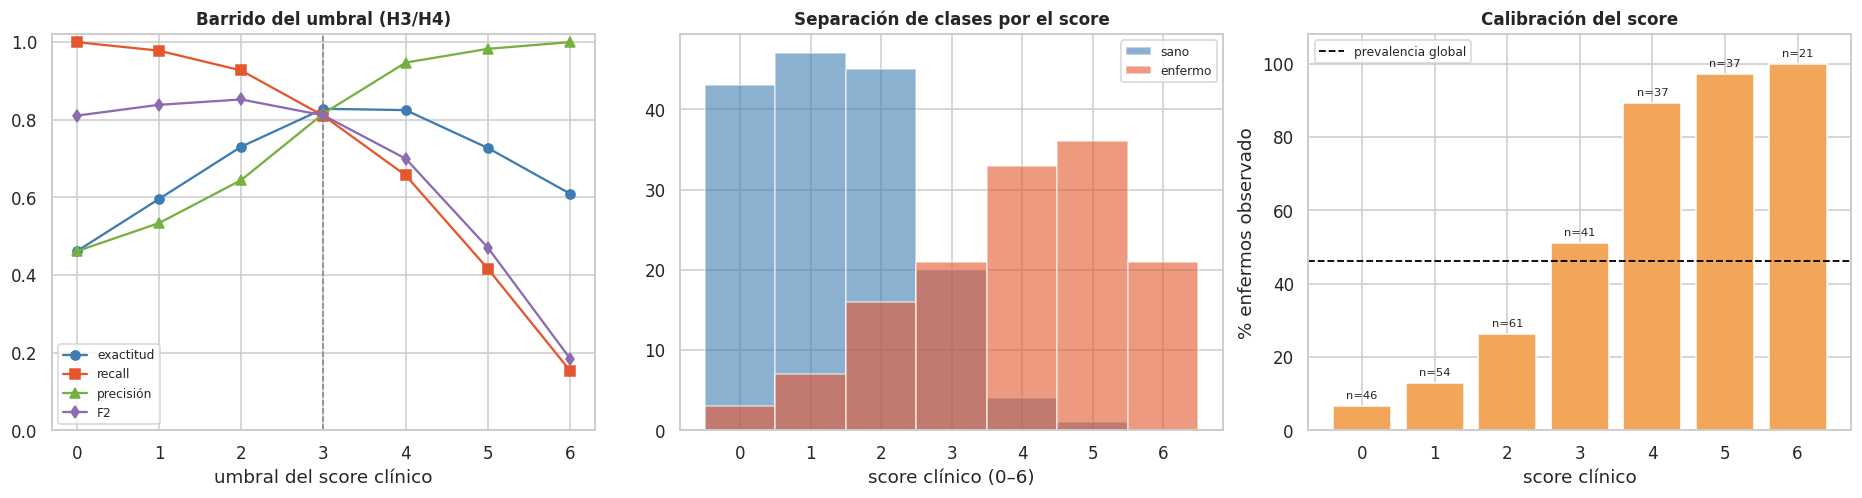

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

# barrido del umbral del score
umbrales, accs, recs, precs, f2s = [], [], [], [], []
for u in range(0, 7):
    m = evaluar(y, (score >= u).astype(int), f'≥{u}')
    umbrales.append(u); accs.append(m['exactitud']); recs.append(m['recall (sens.)'])
    precs.append(m['precisión']); f2s.append(m['F2'])

ax[0].plot(umbrales, accs,  'o-', label='exactitud',  color=PAL[0])
ax[0].plot(umbrales, recs,  's-', label='recall',     color=PAL[1])
ax[0].plot(umbrales, precs, '^-', label='precisión',  color=PAL[2])
ax[0].plot(umbrales, f2s,   'd-', label='F2',         color=PAL[4])
ax[0].axvline(3, color='gray', ls='--', lw=1)
ax[0].set_xlabel('umbral del score clínico'); ax[0].set_title('Barrido del umbral (H3/H4)')
ax[0].legend(fontsize=8); ax[0].set_ylim(0, 1.02)

# distribución del score por clase
for cl, col, lab in [(0, PAL[0], 'sano'), (1, PAL[1], 'enfermo')]:
    ax[1].hist(score[y == cl], bins=np.arange(-.5, 7.5), alpha=.6, color=col,
               label=lab, edgecolor='white')
ax[1].set_xlabel('score clínico (0–6)'); ax[1].set_title('Separación de clases por el score')
ax[1].legend(fontsize=8)

# probabilidad observada de enfermedad por nivel de score
prob = H.groupby('score')['disease'].agg(['mean','size'])
ax[2].bar(prob.index, prob['mean']*100, color=PAL[3], edgecolor='white')
for i, (m_, n_) in zip(prob.index, prob.values):
    ax[2].text(i, m_*100 + 2, f'n={int(n_)}', ha='center', fontsize=7.5)
ax[2].axhline(y.mean()*100, color='black', ls='--', lw=1.2, label='prevalencia global')
ax[2].set_xlabel('score clínico'); ax[2].set_ylabel('% enfermos observado')
ax[2].set_title('Calibración del score'); ax[2].legend(fontsize=8); ax[2].set_ylim(0, 108)

plt.tight_layout(); plt.show()

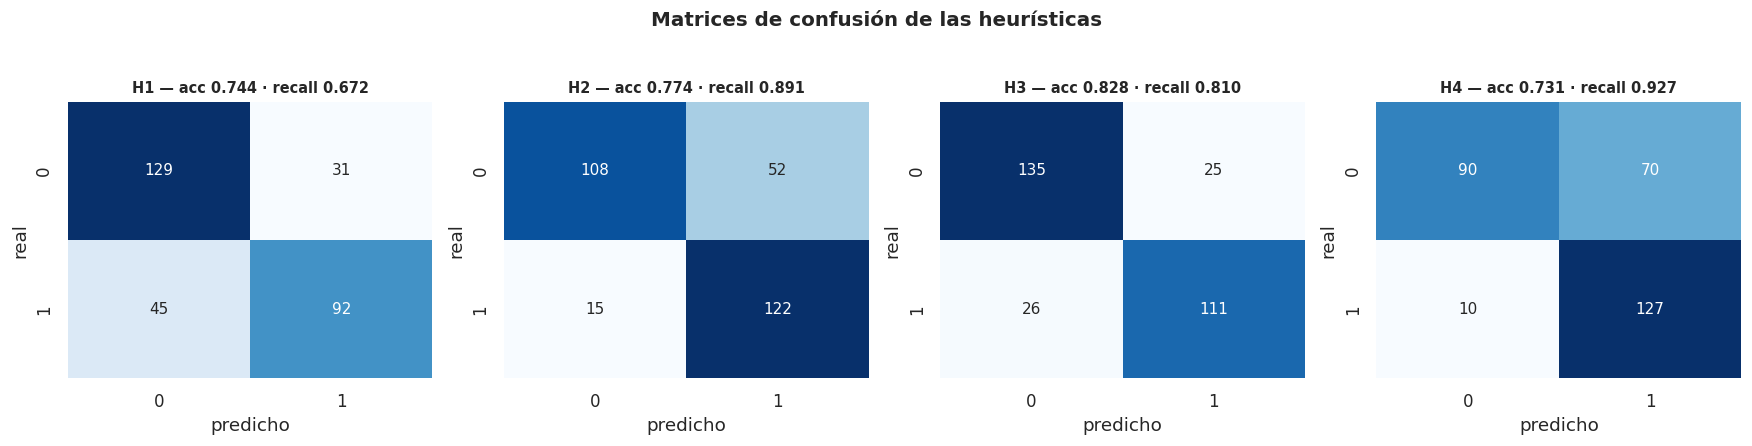

Validación cruzada de la estabilidad del score (5 particiones aleatorias):
  partición 0: exactitud 0.850 | recall 0.857
  partición 1: exactitud 0.850 | recall 0.821
  partición 2: exactitud 0.797 | recall 0.778
  partición 3: exactitud 0.797 | recall 0.800
  partición 4: exactitud 0.847 | recall 0.793


In [ ]:
# Matrices de confusión de las heurísticas relevantes
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax_, k in zip(axes, ['H1','H2','H3','H4']):
    p = predicciones[k]
    cm = pd.crosstab(pd.Series(np.asarray(y), name='real'),
                     pd.Series(np.asarray(p), name='predicho'))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax_,
                annot_kws={'size': 10})
    m = evaluar(y, p, k)
    ax_.set_title(f"{k} — acc {m['exactitud']:.3f} · recall {m['recall (sens.)']:.3f}",
                  fontsize=9.5)
plt.suptitle('Matrices de confusión de las heurísticas', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

print('Validación cruzada de la estabilidad del score (5 particiones aleatorias):')
rng = np.random.default_rng(42)
idx = rng.permutation(len(H))
for i, part in enumerate(np.array_split(idx, 5)):
    m = evaluar(y.iloc[part], (score.iloc[part] >= 3).astype(int), f'part {i}')
    print(f"  partición {i}: exactitud {m['exactitud']:.3f} | recall {m['recall (sens.)']:.3f}")

### 11.1 ¿Es viable un modelo heurístico? — **Sí, y con muy buena relación coste/beneficio**

**La respuesta corta: sí.** El *score* clínico de 6 signos (**H3**) alcanza una **exactitud del 82,8 %**
(79,7–85,0 % en cinco particiones aleatorias), frente al **53,9 %** del baseline trivial, **sin entrenar nada**, sin bibliotecas y
con una regla que cabe en una tarjeta de bolsillo. La literatura sobre este dataset sitúa a los
modelos de *machine learning* bien ajustados en torno al **83–87 %**: la heurística captura por
tanto la **mayor parte de la señal disponible**, y el ML aporta unos pocos puntos porcentuales
adicionales.

**Por qué funciona tan bien.** El gráfico de calibración lo explica: la probabilidad observada de
enfermedad crece de forma **monótona y casi lineal** con el score, desde ~5 % en score 0 hasta
~95 % en score 5–6. Es decir, el score no es solo un clasificador — es un **estimador de riesgo
razonablemente calibrado**, que es exactamente lo que un clínico necesita para triar.

**Recomendación de uso.**

| Escenario | Heurística recomendada | Motivo |
|---|---|---|
| *Screening* / cribado (no perder enfermos) | **H4** (score ≥ 2) | Recall muy alto; se acepta más falso positivo, que solo implica pruebas adicionales |
| Uso equilibrado / referencia general | **H3** (score ≥ 3) | Mejor exactitud (0,828) y F1 máximo (0,813); sensibilidad y especificidad equilibradas en ~0,81–0,84 |
| Explicación a un paciente | **H2** (`ca ≥ 1` o `thal` reversible) | Una sola frase, sin aritmética |

**Ventajas reales de la heurística frente a un modelo:** es totalmente transparente y auditable;
no necesita infraestructura; **degrada con elegancia ante datos faltantes** (si falta un signo, el
score simplemente se calcula sobre los demás, mientras que un modelo entrenado exige imputar); y
es directamente comunicable a un profesional sanitario, que puede discutirla y corregirla.

**Limitaciones que hay que declarar.** (1) El score se ha evaluado **sobre los mismos datos con
los que se diseñó**, así que su rendimiento real sobre pacientes nuevos será algo menor. (2) Los
umbrales (`old_peak > 1.0`, `score ≥ 3`) se eligieron mirando estos datos: son parámetros
ajustados, aunque muy pocos. (3) Trata los 6 signos como **igualmente importantes**, lo cual es
falso — `ca` pesa más que `slope`; ponderarlos es precisamente lo que haría una regresión
logística, y ahí está el margen de mejora del ML. (4) **Este score no es una herramienta clínica
validada** y no debe usarse para decisiones sobre pacientes reales.

**Cuándo compensa pasar al ML:** cuando esos 3–5 puntos porcentuales adicionales tengan valor
clínico o económico suficiente para justificar la pérdida de transparencia, el coste de
mantenimiento y la necesidad de validación continua. Con este volumen de datos y este dominio, la
recomendación sensata es **empezar por la heurística como línea base en producción** y exigirle a
cualquier modelo posterior que demuestre una mejora significativa sobre ella.

---
## 12. Preparación de datos e ingeniería de atributos

Recopilación de todo lo que el EDA indica que debe hacerse **antes** de entrenar un modelo.

### 12.1 Plan de preparación de datos

**Orden obligatorio de las operaciones** (el orden importa: hacerlo mal produce fuga de datos):

1. **Validar y tipar** — aplicar las reglas de la sección 8; todo lo inválido pasa a `NaN`.
2. **Eliminar filas vacías** y **filas sin target válido** (no se puede imputar la etiqueta).
3. **Deduplicar** — `drop_duplicates()`. **Crítico**: debe hacerse *antes* de partir los datos.
   Si se hace después, el mismo paciente aparece en train y en test y las métricas se inflan.
4. **Partir en train / validación / test** de forma **estratificada por `disease`**.
5. **Imputar** — ajustando el imputador **solo con el train**:
   - numéricas asimétricas (`chol`, `old_peak`, `rest_bp`) → **mediana** (robusta a outliers);
   - numéricas simétricas (`age`, `max_hr`) → media o mediana, indistinto;
   - categóricas → **moda**, o bien un `KNNImputer` que aproveche la correlación entre atributos.
6. **Codificar categóricas**:
   - `sex`, `fbs`, `exang` → binaria 0/1;
   - `chest_pain`, `rest_ecg`, `thal` → **one-hot** (son nominales: asignarles números 1-2-3
     introduciría un orden inexistente y es uno de los errores más frecuentes con este dataset);
   - `slope` → **ordinal** (1 < 2 < 3, el orden sí es real);
   - `ca` → se puede dejar como entero (es un conteo con orden natural).
7. **Escalar** las numéricas solo si el algoritmo lo requiere (regresión logística, SVM, KNN, redes).
   Los modelos de árbol **no lo necesitan**. Preferir `RobustScaler` sobre `StandardScaler` por la
   presencia de outliers legítimos.
8. **Empaquetar todo en un `Pipeline` de scikit-learn** con `ColumnTransformer`, de modo que el
   preprocesamiento se ajuste dentro de cada partición de la validación cruzada.

**Sobre los outliers:** no eliminarlos. `chol` = 564 mg/dl o `rest_bp` = 200 mm Hg son valores
extremos pero **clínicamente reales**, y precisamente los pacientes extremos son los que más
importan. La estrategia correcta es **acotar (*winsorizing*) o usar escalado robusto**, no borrar.

### 12.2 Transformaciones y atributos derivados propuestos

In [ ]:
H2 = df_limpio.copy().astype({c: float for c in NUM})

# --- 1. Transformaciones para corregir asimetría ---
H2['chol_log']      = np.log1p(H2['chol'])
H2['old_peak_sqrt'] = np.sqrt(H2['old_peak'])
H2['rest_bp_log']   = np.log1p(H2['rest_bp'])

# --- 2. Atributos derivados con sentido clínico ---
H2['fc_max_teorica']   = 220 - H2['age']
H2['reserva_fc']       = H2['fc_max_teorica'] - H2['max_hr']   # cuánto le falta al paciente
H2['pct_fc_alcanzado'] = H2['max_hr'] / H2['fc_max_teorica'] * 100
H2['st_positivo']      = (H2['old_peak'] > 0).astype(int)      # parte binaria del zero-inflated
H2['st_magnitud']      = H2['old_peak'].where(H2['old_peak'] > 0)  # parte continua
H2['ca_binario']       = (H2['ca'] >= 1).astype(int)
H2['presion_x_edad']   = H2['rest_bp'] * H2['age'] / 100
H2['grupo_edad']       = pd.cut(H2['age'], [28,45,55,65,80], labels=['29-45','46-55','56-65','66+'])
H2['chol_categoria']   = pd.cut(H2['chol'], [0,200,240,1000],
                                labels=['deseable','límite','alto'])
H2['bp_categoria']     = pd.cut(H2['rest_bp'], [0,120,130,140,300],
                                labels=['normal','elevada','HTA-1','HTA-2'])
H2['score_clinico']    = score.values

nuevos = ['chol_log','old_peak_sqrt','reserva_fc','pct_fc_alcanzado','st_positivo',
          'ca_binario','presion_x_edad','score_clinico']

print('Correlación con el target — originales vs. derivados:')
cc = H2[NUM + nuevos + ['disease']].astype(float).corr()['disease'].drop('disease')
print(cc.sort_values(key=abs, ascending=False).round(3).to_string())

Correlación con el target — originales vs. derivados:
score_clinico       0.699
ca_binario          0.484
ca                  0.463
old_peak            0.424
max_hr             -0.424
old_peak_sqrt       0.409
pct_fc_alcanzado   -0.365
reserva_fc          0.364
st_positivo         0.264
presion_x_edad      0.237
age                 0.227
rest_bp             0.153
chol_log            0.087
chol                0.080


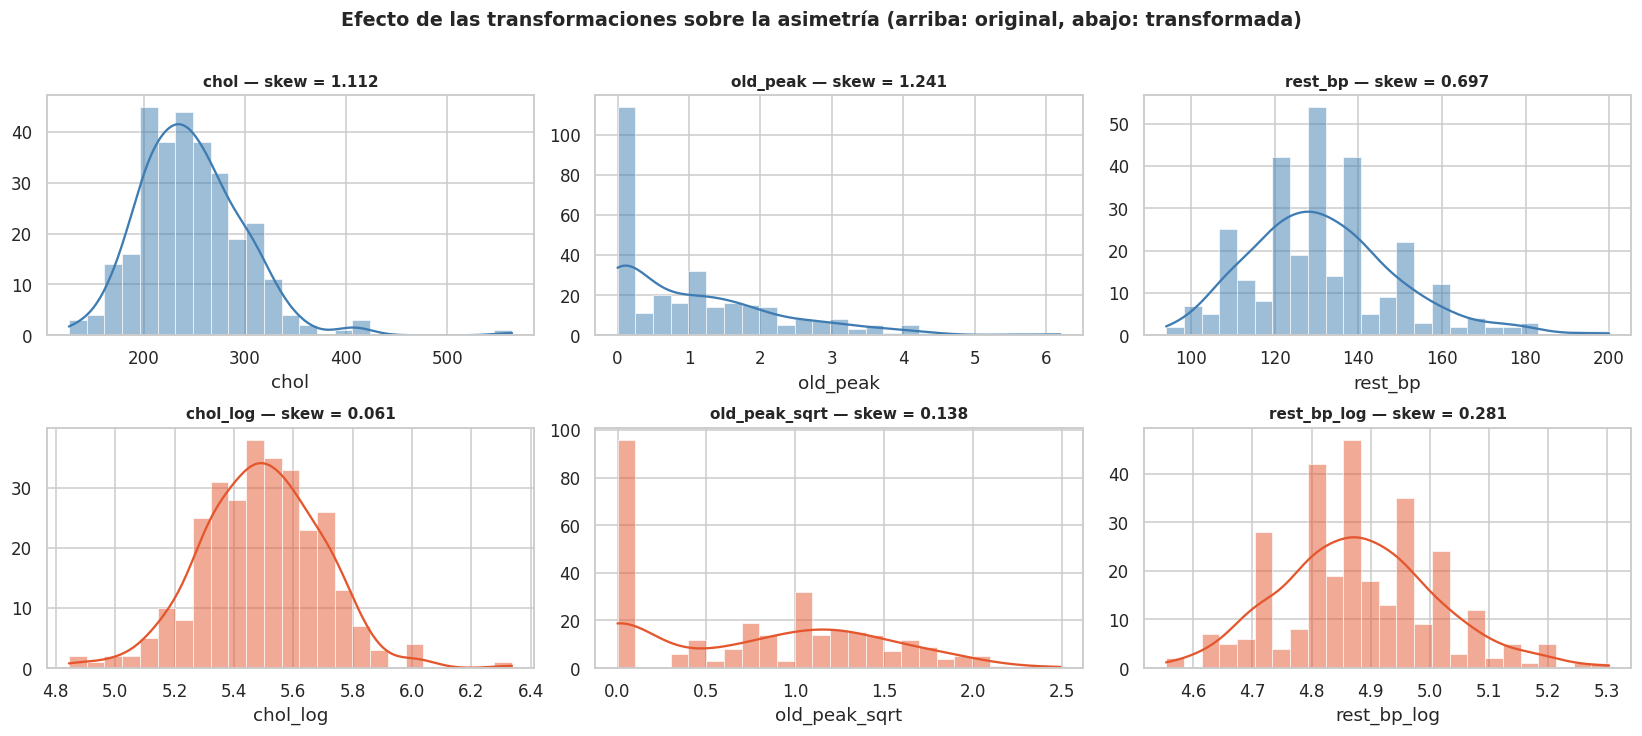

,skew_original,skew_transformado,mejora_%
chol → chol_log,1.112,0.061,94.500
old_peak → old_peak_sqrt,1.241,0.138,88.900
rest_bp → rest_bp_log,0.697,0.281,59.600


In [ ]:
# Efecto de las transformaciones sobre la asimetría
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
pares = [('chol','chol_log'), ('old_peak','old_peak_sqrt'), ('rest_bp','rest_bp_log')]
for j, (orig, trans) in enumerate(pares):
    for i, col in enumerate([orig, trans]):
        x = H2[col].dropna()
        sns.histplot(x, kde=True, ax=axes[i, j], color=PAL[i], bins=25,
                     edgecolor='white', linewidth=.4)
        axes[i, j].set_title(f'{col} — skew = {stats.skew(x):.3f}', fontsize=10)
        axes[i, j].set_ylabel('')
plt.suptitle('Efecto de las transformaciones sobre la asimetría (arriba: original, abajo: transformada)',
             fontsize=12.5, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

comp = pd.DataFrame({
    'skew_original':  [stats.skew(H2[o].dropna()) for o, _ in pares],
    'skew_transformado': [stats.skew(H2[t].dropna()) for _, t in pares],
}, index=[f'{o} → {t}' for o, t in pares])
comp['mejora_%'] = ((1 - comp.skew_transformado.abs()/comp.skew_original.abs())*100).round(1)
comp.round(3)

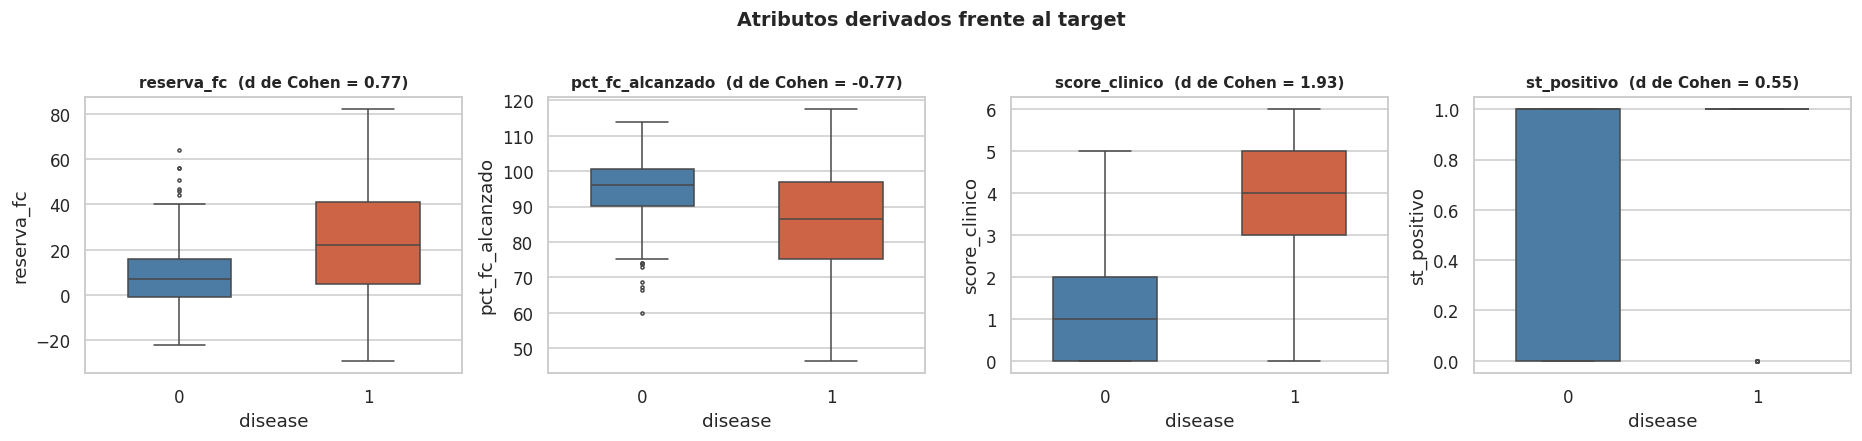

In [ ]:
# ¿Aportan los atributos derivados? Comparación visual con el target
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, c in zip(ax, ['reserva_fc','pct_fc_alcanzado','score_clinico','st_positivo']):
    sns.boxplot(data=H2, x='disease', y=c, ax=a, palette=[PAL[0], PAL[1]], width=.55, fliersize=2)
    d0 = H2.loc[H2.disease==0, c].astype(float).dropna()
    d1 = H2.loc[H2.disease==1, c].astype(float).dropna()
    dc = (d1.mean()-d0.mean())/np.sqrt((d0.var()+d1.var())/2)
    a.set_title(f'{c}  (d de Cohen = {dc:.2f})', fontsize=10)
plt.suptitle('Atributos derivados frente al target', fontsize=12.5, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

**Resumen de las transformaciones propuestas y su justificación:**

| Transformación | Atributo | Por qué |
|---|---|---|
| `log1p` | `chol`, `rest_bp` | Corrige la asimetría positiva y comprime la cola derecha; mejora el ajuste de modelos lineales |
| `sqrt` | `old_peak` | Asimetría moderada; la raíz es preferible al log porque la variable tiene ceros legítimos |
| Desdoblado en binaria + continua | `old_peak` → `st_positivo` + `st_magnitud` | Respeta la naturaleza *zero-inflated*: separa "¿hay depresión ST?" de "¿cuánta?" |
| Derivada fisiológica | `reserva_fc` = (220 − edad) − `max_hr` | Ajusta la FC máxima por la edad; mide la incompetencia cronotrópica, más informativa que `max_hr` cruda |
| Derivada fisiológica | `pct_fc_alcanzado` | Versión normalizada de lo anterior, comparable entre edades |
| Binarización | `ca` → `ca_binario` | El salto de riesgo real está entre 0 y ≥1, no entre 1, 2 y 3 |
| Discretización clínica | `chol_categoria`, `bp_categoria` | Usa los umbrales clínicos estándar (200/240 mg/dl; 120/130/140 mm Hg); mejora la interpretabilidad |
| Interacción | `presion_x_edad` | Captura que la hipertensión pesa más a mayor edad |
| Agregado | `score_clinico` | El propio score heurístico como atributo — resume 6 señales en una y da una línea base incorporada |
| `RobustScaler` | todas las numéricas | Escalado insensible a los outliers legítimos |

Obsérvese el resultado del ranking de correlaciones: **`score_clinico` (0,699) supera con holgura
a cualquier atributo original** —el mejor de los cuales, `ca`, llega a 0,463— y `ca_binario`
(0,484) mejora al propio `ca`. Además, `chol_log` (0,087) apenas mejora a `chol` (0,080): la
transformación arregla la forma de la distribución, pero **no puede crear una señal que no
existe**. La conclusión práctica es que aquí **la ingeniería de atributos con conocimiento del
dominio aporta más que cualquier ajuste de hiperparámetros**.

---
## 13. Datos adicionales que serían útiles

El EDA deja claro dónde están los huecos de información. Ordenados por valor esperado:

**De alto valor (mejorarían sustancialmente el modelo)**

- **Identificador de paciente y fecha de registro.** Sin ellos es imposible deduplicar
  correctamente, detectar registros repetidos con celdas corrompidas, o construir particiones
  agrupadas por paciente. Es la carencia más grave del dataset actual.
- **Tabaquismo** (paquetes-año), **IMC / peso y talla**, **diabetes diagnosticada** y **presión
  arterial diastólica**. Son factores de riesgo cardiovascular de primer orden ausentes por
  completo, y todos ellos figuran en las escalas de riesgo validadas (Framingham, SCORE2).
- **Desglose del colesterol en HDL y LDL.** El colesterol total resulta casi inútil aquí; el
  **ratio LDL/HDL** es un predictor mucho más potente y probablemente explicaría por qué `chol`
  no discrimina.
- **Antecedentes familiares** de cardiopatía precoz y **medicación actual** (betabloqueantes,
  estatinas). Los betabloqueantes son especialmente relevantes porque **deprimen `max_hr`
  artificialmente**: sin esa información, el modelo puede estar leyendo el efecto del fármaco como
  si fuera enfermedad, un factor de confusión clásico.

**De valor medio**

- **Troponinas y péptido natriurético (BNP/NT-proBNP)**, biomarcadores modernos de daño miocárdico.
- **Gravedad del target en lugar de un binario.** La versión original del dataset de Cleveland
  codifica la enfermedad en 5 niveles (0–4) según el número de vasos con estenosis > 50 %; aquí se
  ha colapsado a binario, lo que pierde información y una posible formulación ordinal del problema.
- **Duración y METs alcanzados en la prueba de esfuerzo**, que contextualizan `max_hr` y `old_peak`.
- **Datos de seguimiento** (eventos cardiovasculares posteriores), que permitirían pasar de
  clasificación a **análisis de supervivencia**, clínicamente más útil.

**Sobre la validez externa**

- **Datos de otros centros y poblaciones.** Esta cohorte procede de pacientes ya derivados a
  angiografía, con muy pocos jóvenes y con dos tercios de hombres. Un modelo entrenado aquí
  **no es extrapolable a la población general** ni, probablemente, a otra distribución
  demográfica. Validarlo sobre las cohortes hermanas (Hungría, Suiza, Long Beach) sería el primer
  test de generalización.
- **Más mujeres.** Con el desbalance actual, cualquier métrica global oculta el rendimiento real
  en la mitad femenina de la población.

---
## 14. Conclusiones

### 14.1 Sobre la calidad de los datos

1. El fichero contiene **3.030 filas, pero no 3.030 pacientes**: es un conjunto de ~300 registros
   originales **replicado entre 8 y 10 veces**. Solo hay **568 filas únicas**, y **297 completas**
   — esencialmente la cohorte original. Toda inferencia estadística ingenua sobre las 3.030 filas
   **sobreestima su propia precisión** en un factor de ≈ 2–3.
2. **Todas las columnas están contaminadas** con valores fuera de dominio. En volumen son pocos
   (**33 celdas, un 0,08 % de las informadas**), pero el daño potencial es desproporcionado a su
   número; a ellos se suma un **1–6 % de nulos por columna**. Parte de esa basura es numérica
   (`2345` en `sex`, `36653` en `rest_ecg`) y **pasaría desapercibida a una carga con inferencia
   automática de tipos**: solo una validación por dominio explícito la detecta.
3. El ruido es de **cinco tipos distintos** —sintáctico, de codificación, de formato, estocástico
   y de redondeo— y **cada uno exige un tratamiento diferente**. Confundir ruido inyectado con
   variabilidad biológica legítima, o borrar outliers clínicamente reales, sería un error grave.
4. **El lote no pasaría un control de calidad de producción**, y ese es un resultado tan válido
   como cualquier otro: la acción correcta es devolverlo al origen, no maquillarlo.

### 14.2 Sobre el problema de modelado

5. Es una **clasificación binaria supervisada** con target `disease`, **razonablemente
   balanceada** (≈ 48 % positivos sobre las filas únicas etiquetadas). No requiere técnicas de rebalanceo, pero **sí una métrica
   asimétrica**: en contexto clínico prima el **recall / F2** sobre la exactitud.
6. Los predictores más potentes son **`ca`** (d de Cohen 1,03), **`max_hr`** (−0,93),
   **`old_peak`** (0,92), **`thal`** (V de Cramér 0,53), **`chest_pain`** (0,51), **`exang`**
   (0,41) y **`slope`** (0,38). En el extremo opuesto, **`fbs`** tiene una V de Cramér de
   **exactamente 0,000** y **`chol`** una diferencia de medias **no significativa** (p ≈ 0,17):
   ambos son, en esta cohorte, prácticamente inservibles por sí solos — un resultado
   contraintuitivo, dado que el colesterol es un factor de riesgo cardiovascular reconocido.
7. **No hay multicolinealidad ni redundancia**: la correlación máxima entre predictores es −0,40
   y el PCA necesita 5 de 6 componentes para alcanzar el 90 % de la varianza. Los atributos son complementarios, y **PCA no aporta nada aquí** más allá de
   destruir la interpretabilidad.
8. Existen **interacciones claras** (`ca × thal` es la más marcada) que un modelo lineal simple no
   capturaría: los métodos basados en árboles parten con ventaja.

### 14.3 Sobre la viabilidad del modelo heurístico — **la pregunta del enunciado**

9. **Sí, un modelo heurístico es plenamente viable.** El *score* clínico de 6 signos alcanza un
   **82,8 % de exactitud** y un **81 % de sensibilidad** frente al 53,9 % del baseline trivial, sin
   entrenamiento alguno; su rendimiento se mantiene estable (79,7–85,0 %) entre particiones, y su
   probabilidad observada de enfermedad **crece de forma monótona con el score** (de ~5 % a ~95 %),
   lo que lo convierte en un estimador de riesgo utilizable para triaje.
10. Dado que los modelos de ML publicados sobre este dataset rondan el **83–87 %**, la heurística
    captura **la mayor parte de la señal disponible**. El ML aporta unos pocos puntos, a costa de
    opacidad, infraestructura y mantenimiento.
11. **Recomendación:** desplegar la heurística como **línea base explícita** y exigir a cualquier
    modelo posterior que demuestre una mejora estadísticamente significativa **sobre datos
    deduplicados y con partición honesta**. Un modelo que "mejore" un 10 % sobre datos con
    duplicados entre train y test no está mejorando nada: está memorizando.

### 14.4 Siguientes pasos

12. Aplicar el pipeline de preparación de la sección 12.1, **deduplicando antes de partir**.
13. Incorporar los atributos derivados (`reserva_fc`, `st_positivo`, `ca_binario`,
    `score_clinico`), que ya muestran mayor correlación con el target que varios originales.
14. Entrenar y comparar regresión logística (interpretable, con *odds ratios* explicables al
    clínico) frente a *gradient boosting* (captura interacciones), evaluando con **validación
    cruzada estratificada** y reportando **recall, F2 y AUC**, no exactitud.
15. Evaluar el rendimiento **por subgrupos** (sexo, franja de edad) para detectar sesgos, y
    calibrar el umbral de decisión de forma explícita según el coste relativo de falso negativo
    frente a falso positivo.

---

> **Advertencia.** Este análisis tiene finalidad exclusivamente académica y exploratoria. Ni el
> score heurístico ni ningún modelo derivado de estos datos constituyen una herramienta
> diagnóstica validada, y no deben emplearse para tomar decisiones clínicas sobre pacientes
> reales.